In [387]:
import yaml
from pathlib import Path
from warnings import filterwarnings

In [388]:
filterwarnings('ignore')

In [389]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [390]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder, PowerTransformer
from sklearn.model_selection import train_test_split

In [391]:
# find the root from the project directory
def find_project_root(path):
    """Find the root directory of a Git repository."""
    path = Path(path).resolve()
    while True:
        if (path / '.git').exists():
            return path
        if path.parent == path:
            break
        path = path.parent
    return None

In [392]:
CURR_DIR = Path().resolve()
ROOT_DIR = find_project_root(CURR_DIR)
DATA_PATH = ROOT_DIR / 'data'

---

## data cleaning

In [393]:
dataset = pd.read_csv(DATA_PATH / 'raw_data' / 'mall_customers.csv')
data = dataset.copy(deep=True)

In [394]:
data

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [395]:
new_column_name = {
    'CustomerID': 'customer_id',
    'Gender': 'gender',
    'Age': 'age',
    'Annual Income (k$)': 'annual_income',
    'Spending Score (1-100)': 'spending_score'
}

# normalize column names for convenience
data = data.rename(columns=new_column_name)

In [396]:
data = data.drop(columns=['customer_id'], axis=1)
data['annual_income'] = data['annual_income'] * 1_000

---

### Data versioning

In [397]:
customer_data_version_01 = data.copy(deep=True)
customer_data_version_02 = data.copy(deep=True)

# save both data versions to data_version directory
customer_data_version_01.to_csv(ROOT_DIR/'data'/'data_versions'/'customer_data_version_01.csv', index=False)
customer_data_version_02.to_csv(ROOT_DIR/'data'/'data_versions'/'customer_data_version_02.csv', index=False)

---
___

## EDA with data version 01

In [398]:
data_version01 = pd.read_csv(ROOT_DIR/'data'/'data_versions'/'customer_data_version_01.csv')
df = data_version01.copy(deep=True)
df.head()

,gender,age,annual_income,spending_score
0,Male,19,15000,39
1,Male,21,15000,81
2,Female,20,16000,6
3,Female,23,16000,77
4,Female,31,17000,40


<!-- basic data exploration -->

In [399]:
# selecting numerical features and categorical features

numerical_features = [col for col in df.select_dtypes(include="number").columns if col != "CustomerID"]
categorical_features = df.select_dtypes(include="object").columns.tolist()

print(f"numerical features: {numerical_features}")
print(f"categorical features: {categorical_features}")

numerical features: ['age', 'annual_income', 'spending_score']
categorical features: ['gender']


---
___

# II. Exploratory Data Analysis (EDA)

In [400]:
df.shape

(200, 4)

In [401]:
df.columns

Index(['gender', 'age', 'annual_income', 'spending_score'], dtype='object')

In [402]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   gender          200 non-null    object
 1   age             200 non-null    int64 
 2   annual_income   200 non-null    int64 
 3   spending_score  200 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 6.4+ KB


In [403]:
df.describe()

,age,annual_income,spending_score
count,200.000000,200.000000,200.000000
mean,38.850000,60560.000000,50.200000
std,13.969007,26264.721165,25.823522
min,18.000000,15000.000000,1.000000
25%,28.750000,41500.000000,34.750000
50%,36.000000,61500.000000,50.000000
75%,49.000000,78000.000000,73.000000
max,70.000000,137000.000000,99.000000


### Univariate Analysis

#### Numerical Variable

In [404]:
# summary statistics

print(df[numerical_features].info())
print(df[numerical_features].describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             200 non-null    int64
 1   annual_income   200 non-null    int64
 2   spending_score  200 non-null    int64
dtypes: int64(3)
memory usage: 4.8 KB
None
              age  annual_income  spending_score
count  200.000000     200.000000      200.000000
mean    38.850000   60560.000000       50.200000
std     13.969007   26264.721165       25.823522
min     18.000000   15000.000000        1.000000
25%     28.750000   41500.000000       34.750000
50%     36.000000   61500.000000       50.000000
75%     49.000000   78000.000000       73.000000
max     70.000000  137000.000000       99.000000


#### data distribution: measure of shape

In [405]:
def get_shape_measures(data: pd.DataFrame, feature_list: list[str]) -> dict:
    """Return skewness and kurtosis value of numerical feature
        data: data_frame
        feature_list: numerical feature names
        return : dictionary of skewness and kurtosis value of features and their descriptions
    """
    measure_of_shape = {}
    for feature in feature_list:
        shape = {}
        skew = data[feature].skew()
        kurt = data[feature].kurtosis()

        shape["skew"] = skew
        if skew < -1:
            shape["skew_description"] = "Highly left-skewed"
        elif skew < -0.5:
            shape["skew_description"] = "Moderately left-skewed"
        elif skew < 0:
            shape["skew_description"] = "Slightly left-skewed"
        elif skew == 0:
            shape["skew_description"] = "Symmetric"
        elif skew < 0.5:
            shape["skew_description"] = "Slightly right-skewed"
        elif skew < 1:
            shape["skew_description"] = "Moderately right-skewed"
        else:
            shape["skew_description"] = "Highly right-skewed"

        shape["kurt"] = kurt
        if kurt < 2:
            shape["kurt_description"] = "Very platykurtic(flat)"
        elif kurt < 3:
            shape["kurt_description"] = "Platykurtic(less peaked)"
        elif kurt == 3:
            shape["kurt_description"] = "Mesokurtic(normal)"
        elif kurt < 4:
            shape["kurt_description"] = "Leptokurtic(more peaked)"
        else:
            shape["kurt_description"] = "Very leptokurtic(very peaked)"
        
        measure_of_shape[feature] = shape
    return measure_of_shape

In [406]:
measure_shape = get_shape_measures(df, numerical_features)
pd.DataFrame(measure_shape)

,age,annual_income,spending_score
skew,0.485569,0.321843,-0.04722
skew_description,Slightly right-skewed,Slightly right-skewed,Slightly left-skewed
kurt,-0.671573,-0.098487,-0.826629
kurt_description,Very platykurtic(flat),Very platykurtic(flat),Very platykurtic(flat)


In [407]:
def univariate_numerical_plots(data: pd.DataFrame, feature: str) -> plt.subplot:
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
    
    # Histogram
    sns.histplot(data=data, x=feature, ax=axes[0, 0], kde=True)
    axes[0, 0].set_title(f"Histogram of {feature}")
    
    # Density Plot
    sns.kdeplot(data=data, x=feature, ax=axes[0, 1], fill=True)
    axes[0, 1].set_title(f"Density Plot of {feature}")
    
    # Boxplot
    sns.boxplot(data=data, x=feature, ax=axes[1, 0])
    axes[1, 0].set_title(f"Boxplot of {feature}")
    
    # QQ Plot
    # Note: Seaborn does not have a built-in QQ plot function.
    # We will use scipy.stats.probplot instead.
    from scipy import stats
    stats.probplot(data[feature], dist="norm", plot=axes[1, 1])
    axes[1, 1].set_title(f"QQ Plot of {feature}")
    plt.suptitle(f"Univariate plot: {feature}")
    
    plt.tight_layout()
    plt.show()

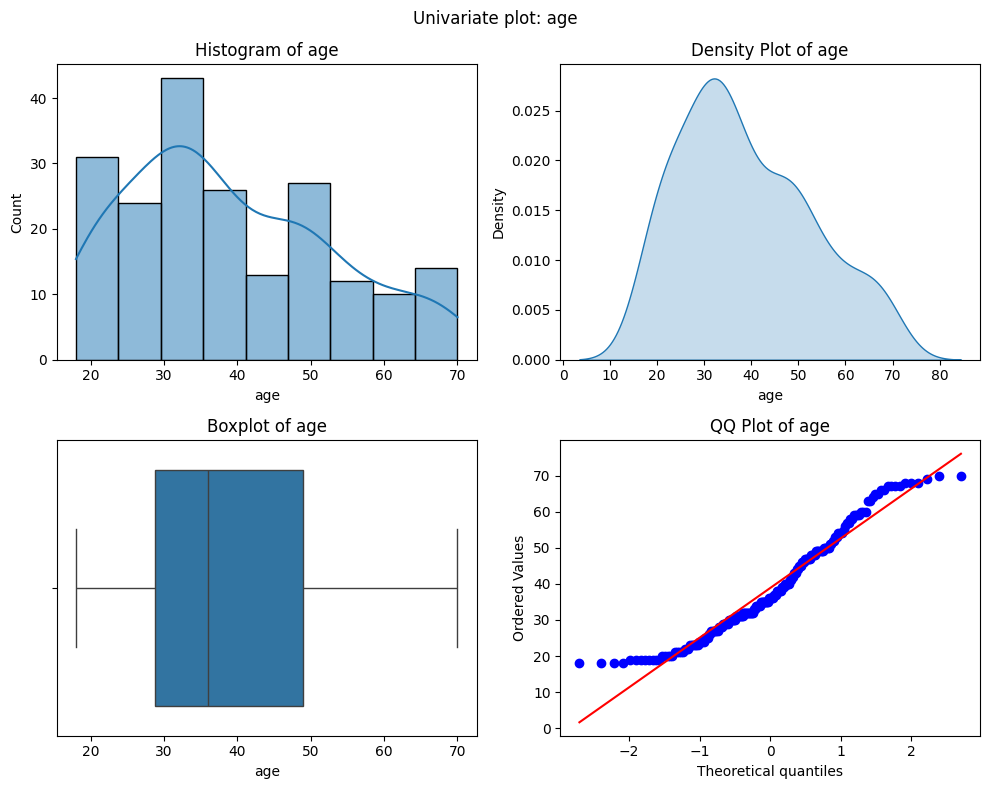

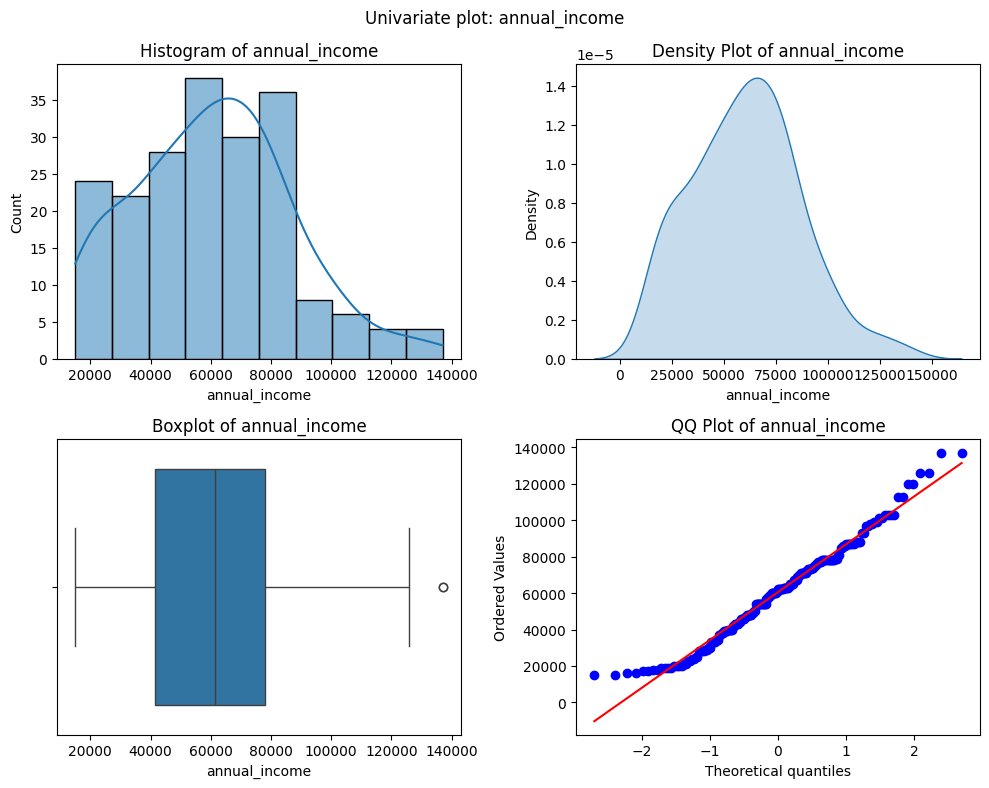

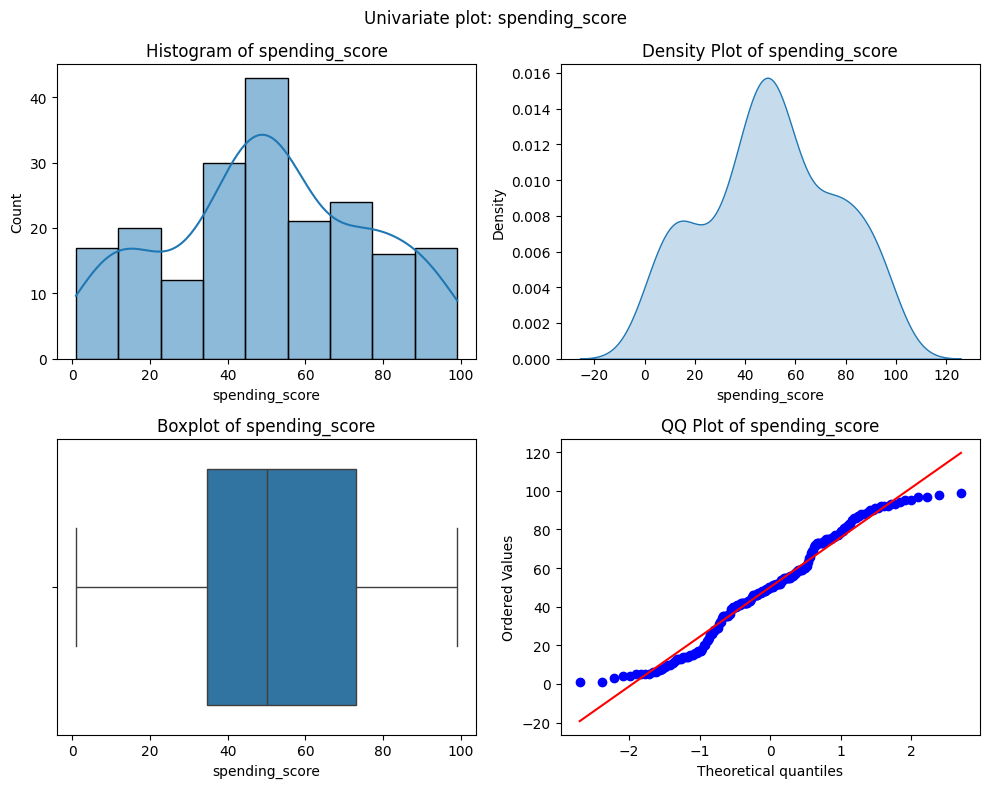

In [408]:
for feature in numerical_features:
    univariate_numerical_plots(df, feature)

from the univariate analysis it is found that lightly right skewed
- so we need to to feature transformation suitably, log transformation or yeo-johnson
- outliers are not found in any numerical features except in annual income (1), presumably the not a anomaly but the normal data

##### Categorical Features

In [409]:
def univariate_categorical_plots(data: pd.DataFrame, categorical_features: list[str]) -> None:
    ncols = 2
    nrows = (len(categorical_features) + ncols - 1) // ncols
    
    fig, axes = plt.subplots(ncols=ncols, nrows=nrows, figsize=(12, 6*nrows))
    
    for i, feature in enumerate(categorical_features):
        if nrows == 1:  # if there's only one row
            ax = axes[i % ncols]
        else:
            ax = axes[i // ncols, i % ncols]
        
        sns.countplot(data=data, x=feature, ax=ax)
        ax.set_title(f"Count Plot: {feature}")
    
    # hide any unused subplots
    for i in range(len(categorical_features), nrows * ncols):
        if nrows == 1:
            ax = axes[i % ncols]
        else:
            ax = axes[i // ncols, i % ncols]
        ax.axis('off')
    
    plt.suptitle("Univariate plots of Categorical features")
    plt.tight_layout()
    
    plt.show()


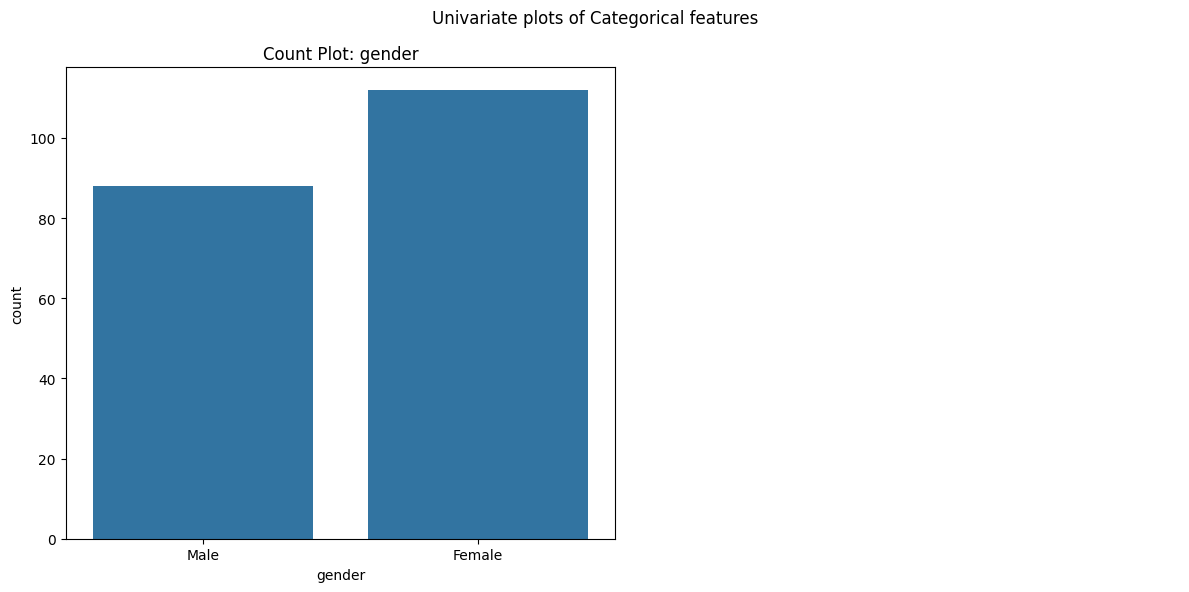

In [410]:
univariate_categorical_plots(df, categorical_features)

from the count plot we could see that :
- Gender is slightly imbalanced: Female (112) vs Male (88) → for clustering, this is usually fine since clustering is unsupervised
- or we could use clustering algorithm robust to outliers such as DBSCAN

### Bivariate Analysis

##### Numerical vs Numerical

correalation and covariance

In [411]:
def correlation_matrix(data: pd.DataFrame, numerical_features: list[str]) -> dict:
    correlation_values = {}
    correlation_values['pearson_correlation'] = df[numerical_features].corr(method='pearson')
    correlation_values['spearman_correlation'] = df[numerical_features].corr(method='spearman')
    correlation_values['kendall_correlation'] = df[numerical_features].corr(method='kendall')
    return correlation_values

In [412]:
# Pearson's Correlation matrix
corr_matrix_pearson = correlation_matrix(df, numerical_features)['spearman_correlation']
corr_matrix_pearson

,age,annual_income,spending_score
age,1.000000,0.019767,-0.34494
annual_income,0.019767,1.000000,0.00784
spending_score,-0.344940,0.007840,1.00000


In [413]:
# Spearman Correlation matrix
corr_matrix_spearman = correlation_matrix(df, numerical_features)['spearman_correlation']
corr_matrix_spearman

,age,annual_income,spending_score
age,1.000000,0.019767,-0.34494
annual_income,0.019767,1.000000,0.00784
spending_score,-0.344940,0.007840,1.00000


In [414]:
# Kendall Correlation matrix
corr_matrix_kendall = correlation_matrix(df, numerical_features)['kendall_correlation']
corr_matrix_kendall

,age,annual_income,spending_score
age,1.000000,0.008198,-0.210757
annual_income,0.008198,1.000000,-0.000765
spending_score,-0.210757,-0.000765,1.000000


In [415]:
cov_matrix = df[numerical_features].cov()
cov_matrix

,age,annual_income,spending_score
age,195.133166,-4.548744e+03,-118.040201
annual_income,-4548.743719,6.898356e+08,6716.582915
spending_score,-118.040201,6.716583e+03,666.854271


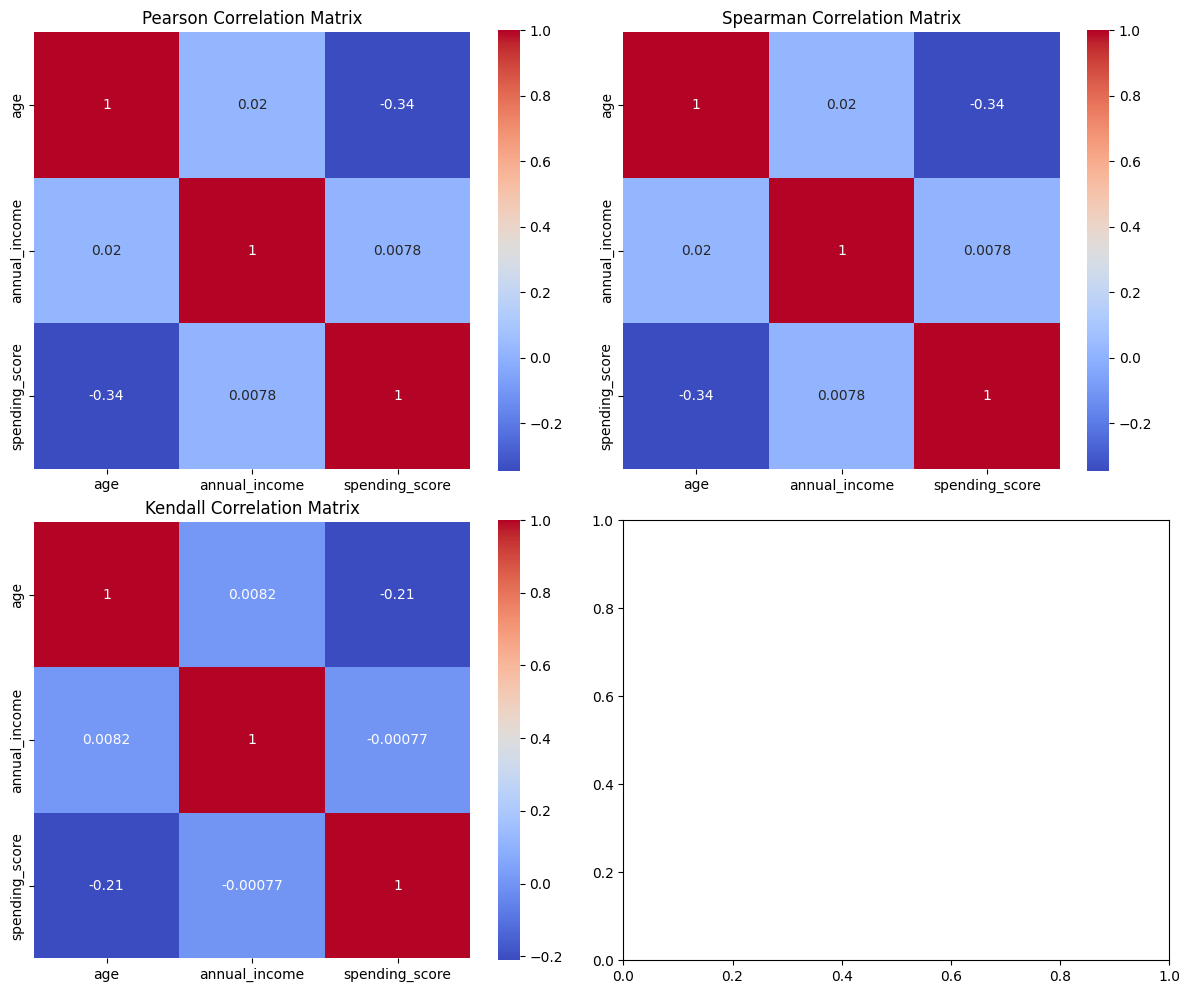

In [416]:
# Create a 2x2 subplot
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Plot the Pearson correlation matrix
sns.heatmap(corr_matrix_pearson, annot=True, cmap='coolwarm', square=True, ax=axs[0, 0])
axs[0, 0].set_title('Pearson Correlation Matrix')

# Plot the Spearman correlation matrix
sns.heatmap(corr_matrix_spearman, annot=True, cmap='coolwarm', square=True, ax=axs[0, 1])
axs[0, 1].set_title('Spearman Correlation Matrix')

# Plot the Kendall correlation matrix
sns.heatmap(corr_matrix_kendall, annot=True, cmap='coolwarm', square=True, ax=axs[1, 0])
axs[1, 0].set_title('Kendall Correlation Matrix')
'''
# Plot the covariance matrix
sns.heatmap(cov_matrix, annot=True, cmap='coolwarm', square=True, ax=axs[1, 1])
axs[1, 1].set_title('Covariance Matrix')
'''
# Layout so plots do not overlap
fig.tight_layout()

plt.show()

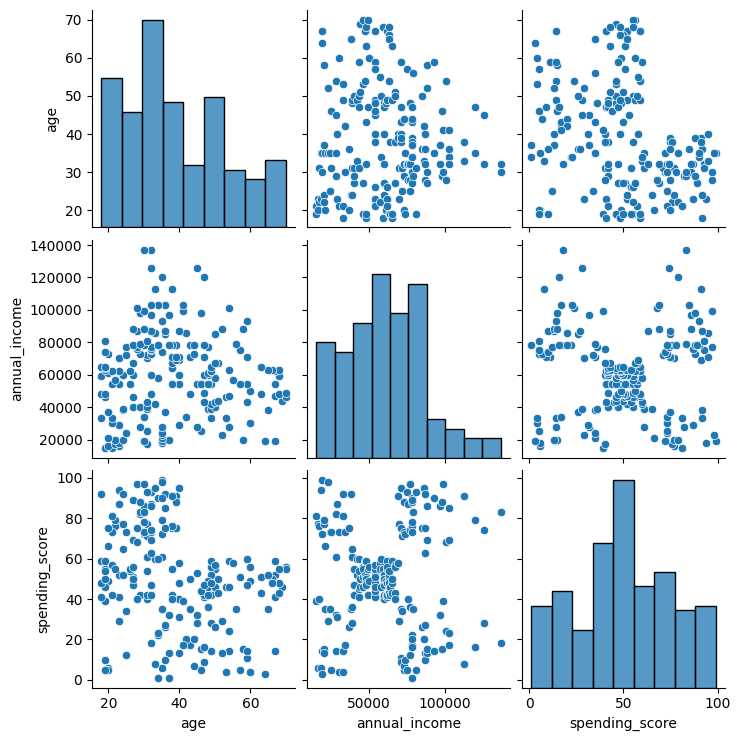

In [417]:
# Pairplot
sns.pairplot(df[numerical_features])
plt.show()

#### Numerical vs Categorical

##### group-wise statistics

In [418]:
# Gender vs Age

gender_age_status = df.groupby('gender')[['age']].agg([ 'mean', 'median', 'std'])
print("Gender-Age statistics:\n")
result = pd.DataFrame(gender_age_status)
result.T

Gender-Age statistics:



gender         Female       Male
age mean    38.098214  39.806818
    median  35.000000  37.000000
    std     12.644095  15.514812

In [419]:
# gender vs annual income
gender_annualincome_status = df.groupby('gender')[['annual_income']].agg([ 'mean', 'median', 'std'])
print("Gender-AnnualIncome statistics:\n")
result = pd.DataFrame(gender_annualincome_status)
result.T

Gender-AnnualIncome statistics:



gender                      Female          Male
annual_income mean    59250.000000  62227.272727
              median  60000.000000  62500.000000
              std     26011.951515  26638.373182

In [420]:
# Gender vs SpendingScore
gender_spendingscore_status = df.groupby('gender')[['spending_score']].agg([ 'mean', 'median', 'std'])
print("Gender-SpendingScore statistics:\n")
result = pd.DataFrame(gender_spendingscore_status)
result

Gender-SpendingScore statistics:



spending_score                 
                 mean median       std
gender                                
Female      51.526786   50.0  24.11495
Male        48.511364   50.0  27.89677

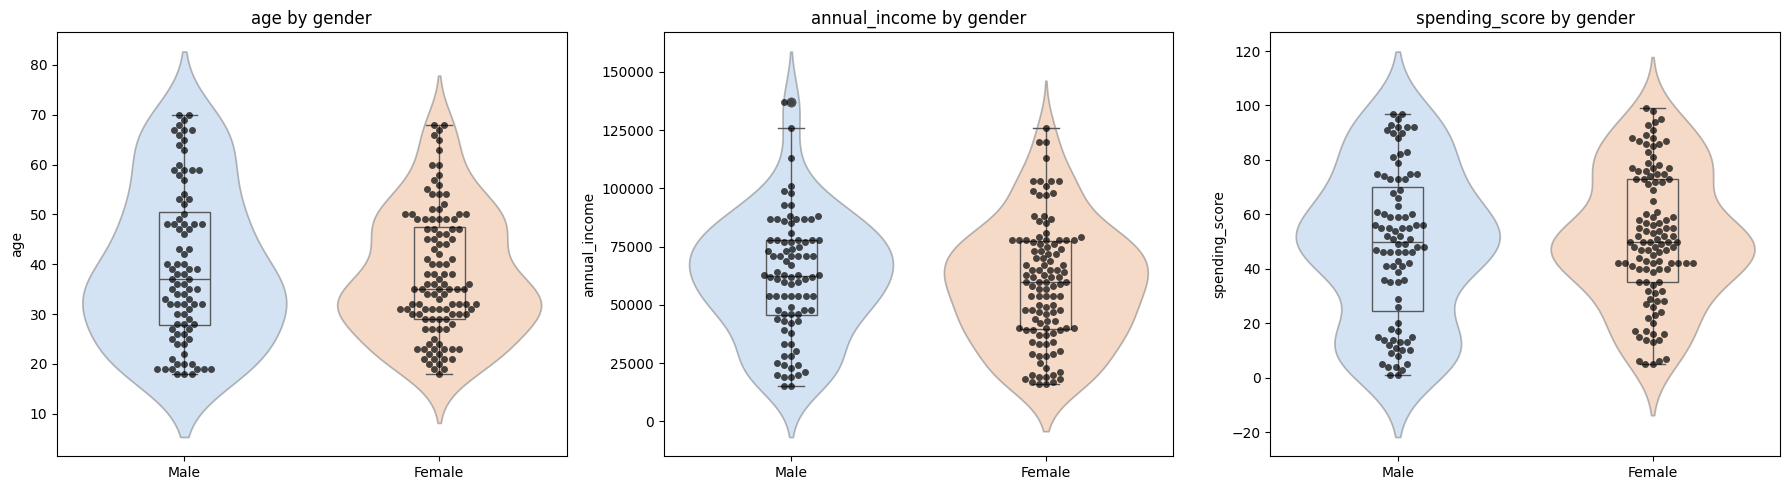

In [421]:
# Combined plot: Box + Violin + Swarm

plt.figure(figsize=(18, 5))
for i, feature in enumerate(numerical_features):
    plt.subplot(1, 3, i+1)
    
    # Violin plot (distribution + density)
    sns.violinplot(x='gender', y=feature, data=df, inner=None, hue='gender', palette='pastel', alpha=0.5, legend=False)
    
    # Boxplot (quartiles + median)
    sns.boxplot(x='gender', y=feature, data=df, width=0.2, hue='gender', palette='Set2', showcaps=True, boxprops={'facecolor':'None'}, showfliers=True, legend=False)
    
    # Swarmplot (individual points)
    sns.swarmplot(x='gender', y=feature, data=df, color='k', alpha=0.7)
    
    plt.title(f'{feature} by gender')
    plt.xlabel('')
    plt.ylabel(feature)
    
plt.tight_layout()
plt.show()

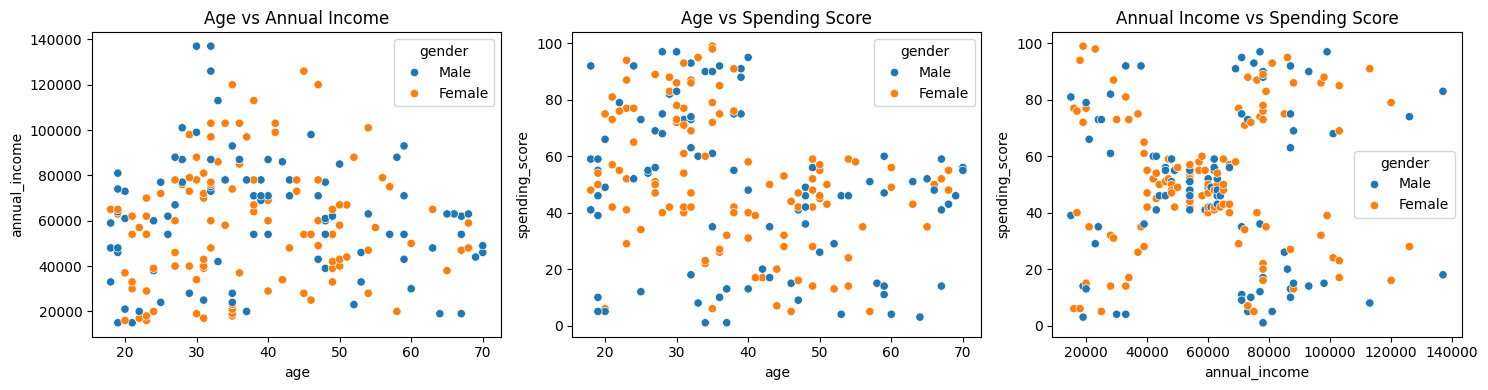

In [422]:
# Individual scatter plots
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
sns.scatterplot(x='age', y='annual_income', data=df, hue='gender', hue_order=['Male', 'Female'])
plt.title('Age vs Annual Income')

plt.subplot(1, 3, 2)
sns.scatterplot(x='age', y='spending_score', data=df, hue='gender', hue_order=['Male', 'Female'])
plt.title('Age vs Spending Score')

plt.subplot(1, 3, 3)
sns.scatterplot(x='annual_income', y='spending_score', data=df, hue='gender', hue_order=['Male', 'Female'])
plt.title('Annual Income vs Spending Score')

plt.tight_layout()
plt.show()


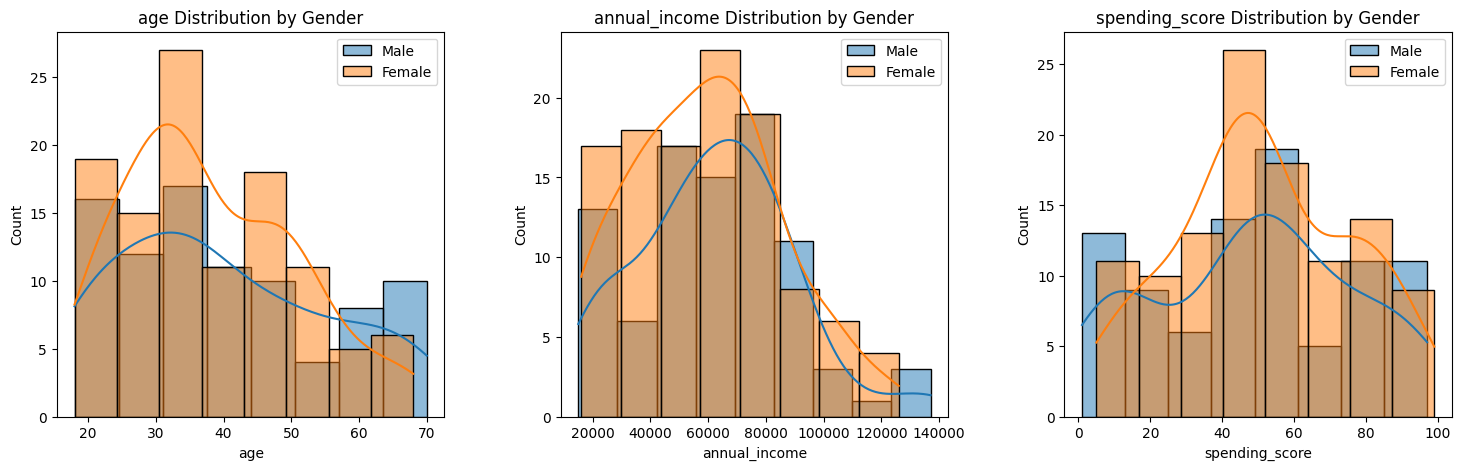

In [423]:
# Distribution plots by category (Optional)
plt.figure(figsize=(18, 5))
for i, feature in enumerate(numerical_features):
    plt.subplot(1, 3, i+1)
    for gender in df['gender'].unique():
        sns.histplot(df[df['gender']==gender][feature], label=gender, kde=True, alpha=0.5)
    plt.title(f'{feature} Distribution by Gender')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.legend()
plt.subplots_adjust(wspace=0.3, hspace=0.3)  
plt.show()

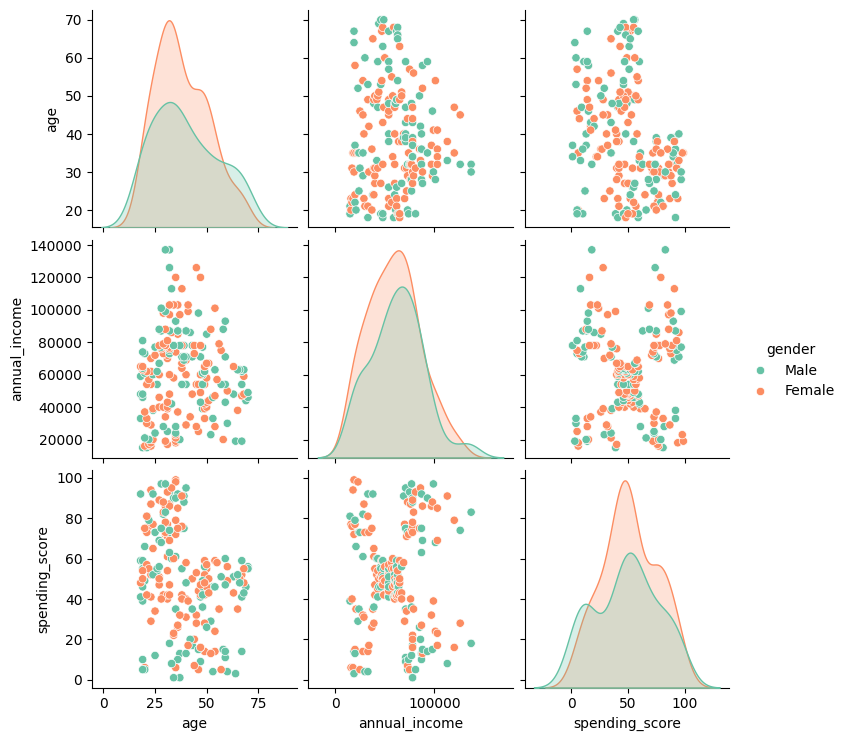

In [424]:
# Pairplot including Gender (optional for categorical insight)
sns.pairplot(df, vars=numerical_features, hue='gender', palette='Set2')
plt.show()

### Multivariate Analysis

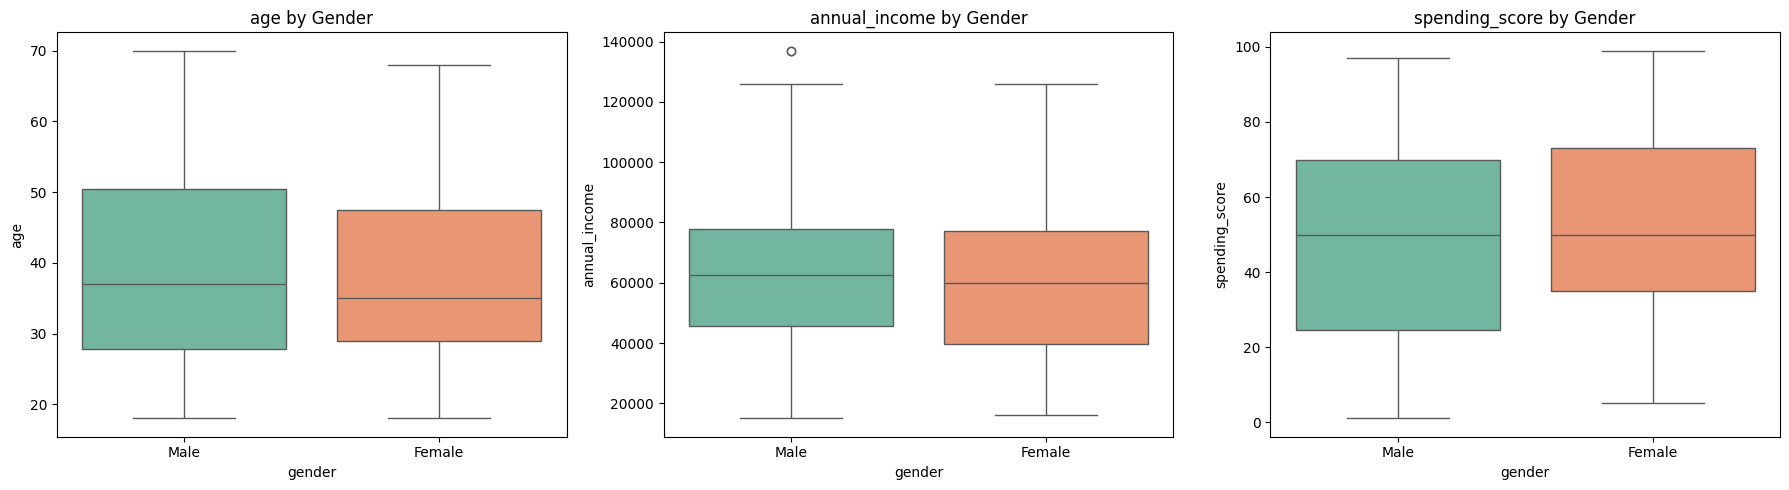

In [425]:
## 4.2 Boxplots
plt.figure(figsize=(18, 5))
for i, feature in enumerate(numerical_features):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x='gender', y=feature, data=df, palette="Set2")
    plt.title(f"{feature} by Gender")
plt.tight_layout()
plt.show()


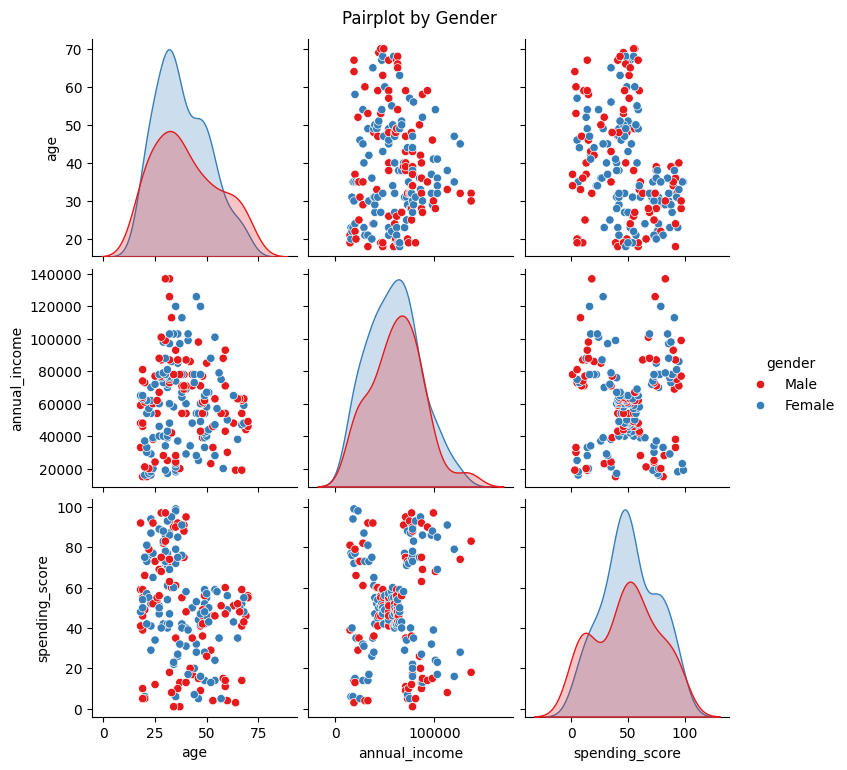

In [426]:
## 6.1 Pairplot Colored by Gender
sns.pairplot(df, vars=numerical_features, hue="gender", diag_kind='kde', palette="Set1")
plt.suptitle("Pairplot by Gender", y=1.02)
plt.show()

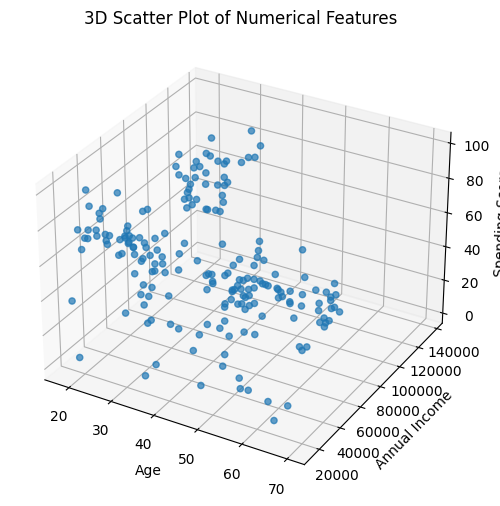

In [427]:
## 3.3 3D Scatter Plot
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['age'], df['annual_income'], df['spending_score'], alpha=0.7)
ax.set_xlabel('Age')
ax.set_ylabel('Annual Income')
ax.set_zlabel('Spending Score')
plt.title("3D Scatter Plot of Numerical Features")
plt.show()

(c) Multicollinearity Check (VIF)

In [428]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

X = df[numerical_features]
X = sm.add_constant(X)  # add intercept
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

          Feature        VIF
0           const  23.359560
1             age   1.120023
2   annual_income   1.000192
3  spending_score   1.119961




The VIF values indicate the level of multicollinearity between the features. A high VIF value (typically > 5 or 10) suggests that a feature is highly correlated with one or more other features.

**Observations**:
Based on the VIF values you provided:

- The constant term has a very high VIF value (23.359560), which is not unusual.
- The Age feature has a relatively low VIF value (1.120023), indicating low correlation with other features.
- The AnnualIncome feature has a very low VIF value (1.000192), suggesting almost no correlation with other features.
- The SpendingScore feature also has a relatively low VIF value (1.119961), indicating low correlation with other features.

**Conclusion**:
Overall, the VIF values suggest that there is no significant multicollinearity between the features in your dataset. This is a good indication that your features are relatively independent and can be used together in a model without worrying about multicollinearity issues.


## Summary of EDA:
- no missing values
- only 1 outlier which need not to handle
- numerical features are lighly positvely skewed
- significant problem of multicollinearity
    - recommaded yeo-johnson or log transformation for better clustering
- standardization or normalization should be applied for better clustering
- only one categorical feature available which is norminal in nature
    - one hot encoding

- featture creation may approprate for capture relationships
- feature selection / dimensionality reduction is not neccessary as the features are few
- result from 3d plots, scatter plots give us the tale tell sign of possbile clustering nauture of the data


---
---

# III. Data Preprocessing

In [429]:
df.head()

,gender,age,annual_income,spending_score
0,Male,19,15000,39
1,Male,21,15000,81
2,Female,20,16000,6
3,Female,23,16000,77
4,Female,31,17000,40


***

## Data Cleaning

- some of the data cleaning part allredy done in the begining,, for the data versioning , including:
    - normalize the colufeature names
    - remove redudant `CustomerID` feature
    

---

## Imputation

In [430]:
# number of missing valaues
df.isnull().sum()

gender            0
age               0
annual_income     0
spending_score    0
dtype: int64

In [431]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   gender          200 non-null    object
 1   age             200 non-null    int64 
 2   annual_income   200 non-null    int64 
 3   spending_score  200 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 6.4+ KB


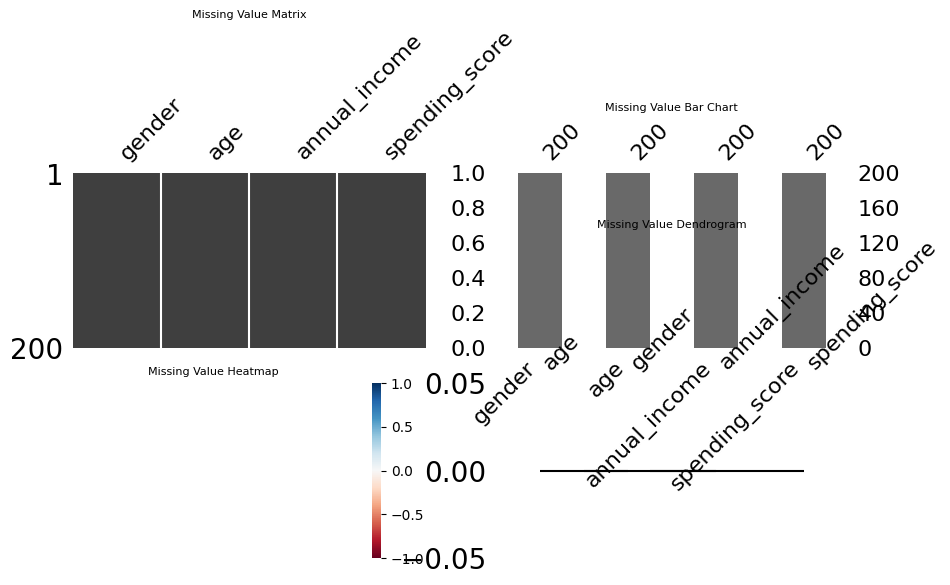

In [432]:
import missingno as msno

# Visualizing missing values
fig, axes = plt.subplots(2, 2, figsize=(10, 5))
msno.matrix(df, ax=axes[0, 0])
axes[0, 0].set_title('Missing Value Matrix', fontsize=8)
msno.bar(df, ax=axes[0, 1])
axes[0, 1].set_title('Missing Value Bar Chart', fontsize=8)
msno.heatmap(df, ax=axes[1, 0])
axes[1, 0].set_title('Missing Value Heatmap', fontsize=8)
msno.dendrogram(df, ax=axes[1, 1])
axes[1, 1].set_title('Missing Value Dendrogram', fontsize=8)
plt.tight_layout()
plt.show()


---

## Outlier Handling

in the dataset, it was identified one outlier in the Annual Income feature, which corresponds to the maximum value. This outlier is presumably not an erroneous data point but rather an extreme value that appears in the data.

Handling Outliers:
When dealing with outliers, it's essential to consider the context and the goals of your analysis. Here are some common strategies for handling outliers:

- Do nothing: If the outlier is legitimate and not an error, you may choose to leave it in the dataset.
- Transform the data: Applying transformations, such as logarithmic or square root, can help reduce the impact of outliers.
- Employ robust methods: Use robust statistical methods, such as the median and interquartile range (IQR), which are less affected by outliers.
- Remove the outlier: If the outlier is deemed to be an error or is significantly impacting your analysis, you may choose to remove it.

In [433]:
# maximum value of annual_income
df['annual_income'].max()

137000

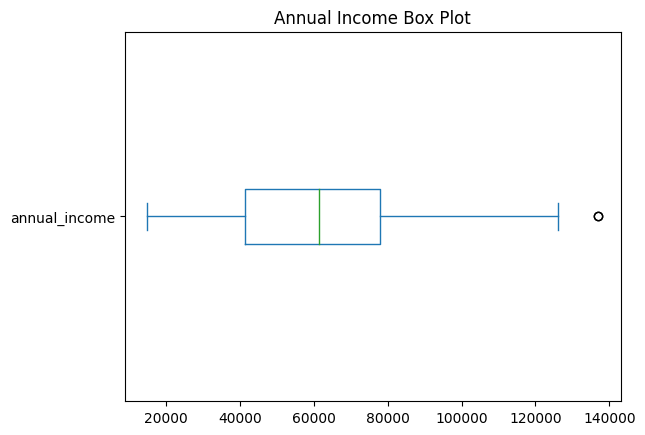

In [434]:
df['annual_income'].plot(kind='box', vert=False)
plt.title('Annual Income Box Plot')
plt.show()

---

## Data Transformation 

- from the bi variate anlsysis, it seems that the distributions of age, annual_income, and spending_score are slightly skewed.
    - It's generally recommended to apply transformations only to the features that require it, rather than applying it to all features.

    - `age` and `annual_income` are slightly right-skewed, you may consider applying a transformation to these features. 
    - However, `spending_score` is slightly left-skewed, so it may not require a transformation.
    - since most of the clustering alogirthms rely on distance meassure, skweness may affect the clustering 
    - based on the skewness valaue we could either perform `log` transformation or `yeo-johnson` transformation
    - Apply Yeo-Johnson transformation to age and annual_income features.



Before transformation of `age`, `annual_income`

In [435]:
result = get_shape_measures(df, ['age', 'annual_income'])
pd.DataFrame(result)

,age,annual_income
skew,0.485569,0.321843
skew_description,Slightly right-skewed,Slightly right-skewed
kurt,-0.671573,-0.098487
kurt_description,Very platykurtic(flat),Very platykurtic(flat)


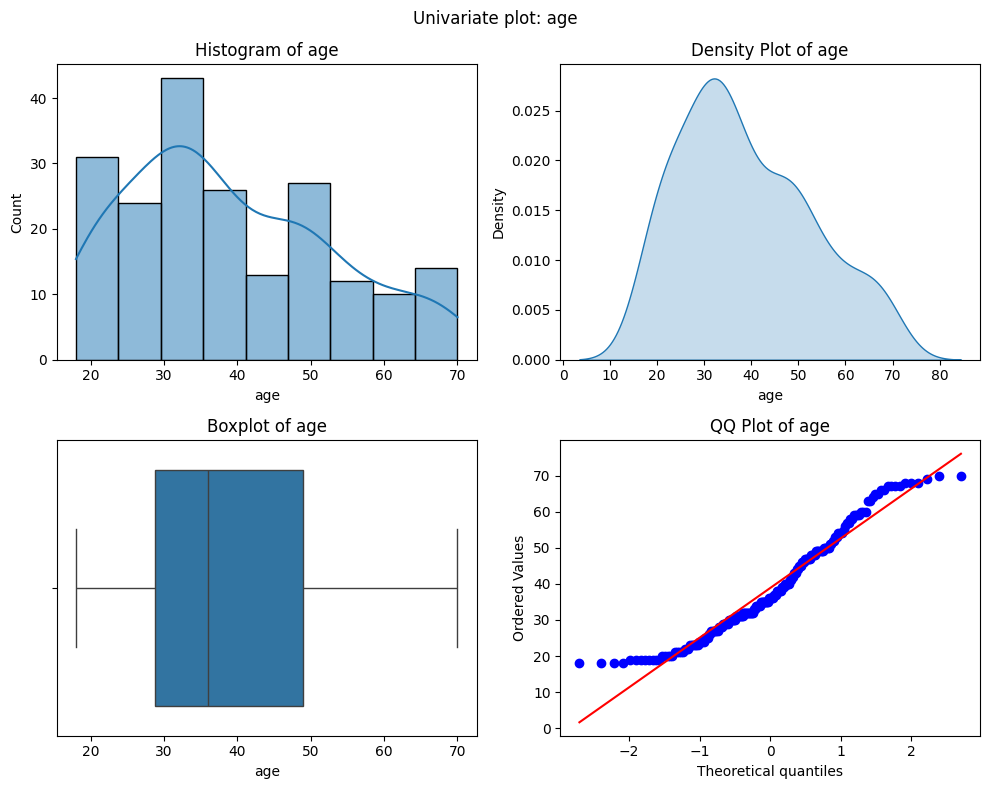

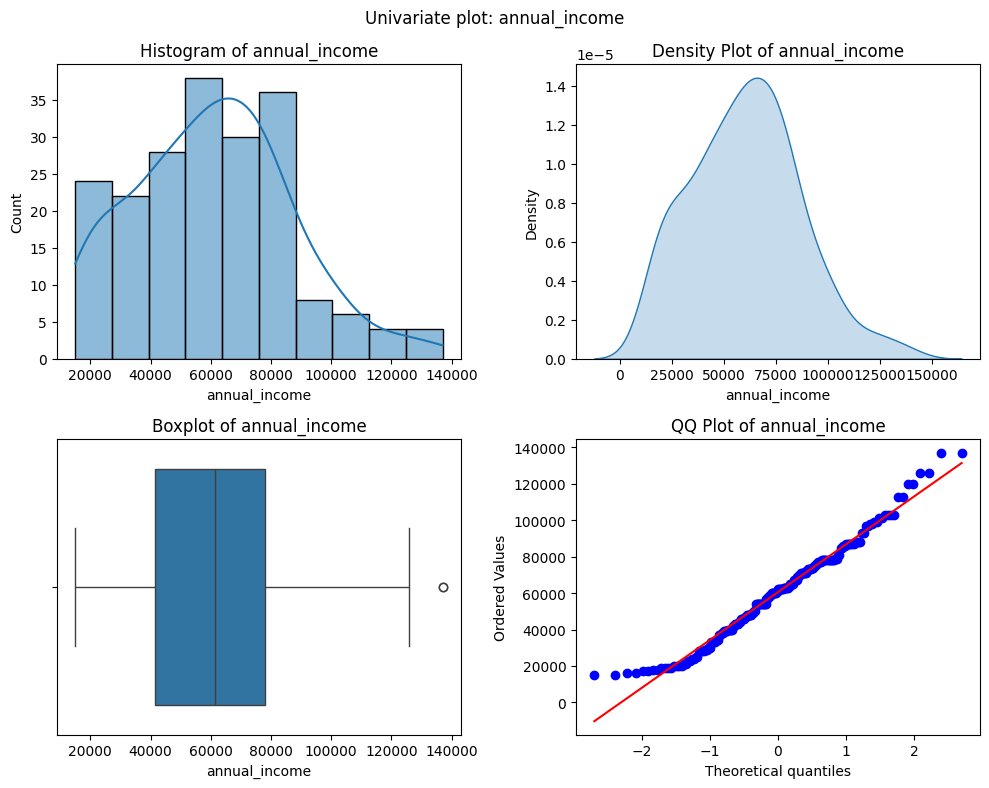

In [436]:
# data distribution before transformation

univariate_numerical_plots(df, 'age')
univariate_numerical_plots(df, 'annual_income')

##### **transformation**

In [437]:

from scipy.stats import yeojohnson

# Apply Yeo-Johnson transformation to age and annual_income features
df['age_transformed_yj'] = yeojohnson(df['age'])[0]
df['annual_income_transformed_yj'] = yeojohnson(df['annual_income'])[0]


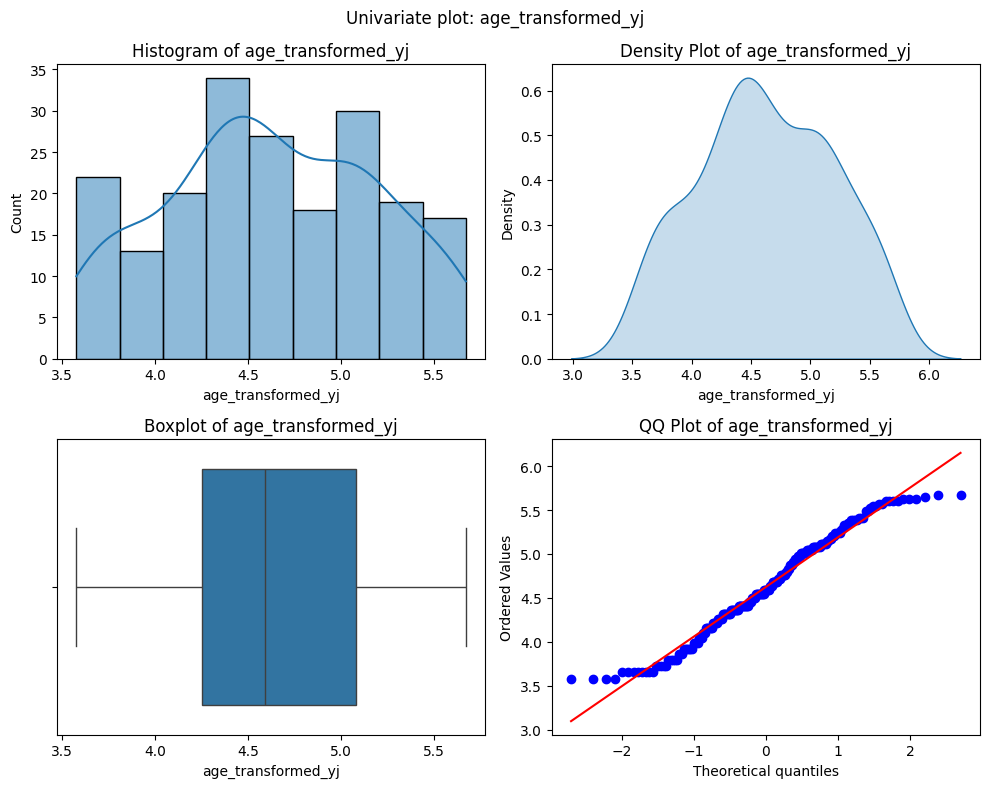

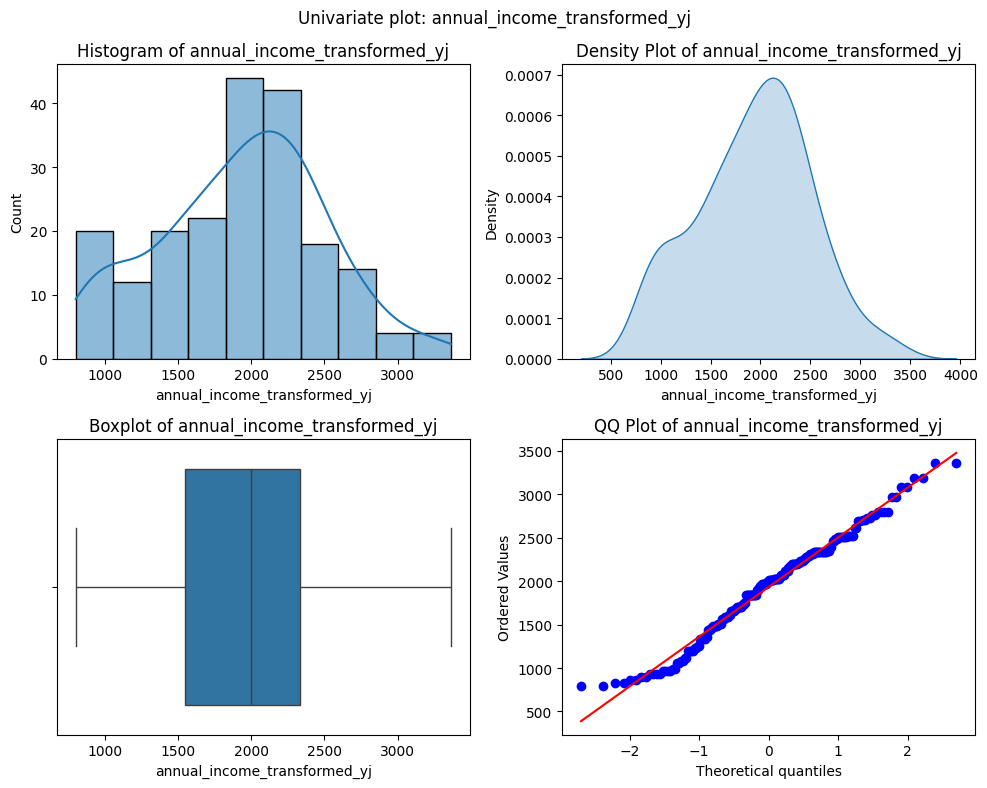

In [438]:
univariate_numerical_plots(df, 'age_transformed_yj')
univariate_numerical_plots(df, 'annual_income_transformed_yj')

In [439]:
result = get_shape_measures(df, ['age_transformed_yj', 'annual_income_transformed_yj'])
pd.DataFrame(result)

,age_transformed_yj,annual_income_transformed_yj
skew,-0.013855,-0.066399
skew_description,Slightly left-skewed,Slightly left-skewed
kurt,-0.896728,-0.409576
kurt_description,Very platykurtic(flat),Very platykurtic(flat)


In [440]:

# Apply log transformation to age and annual_income features (for positive values)
# Add 1 to avoid issues with zero values

df['age_log'] = np.log(df['age'] + 1) 
df['annual_income_log'] = np.log(df['annual_income'] + 1)  


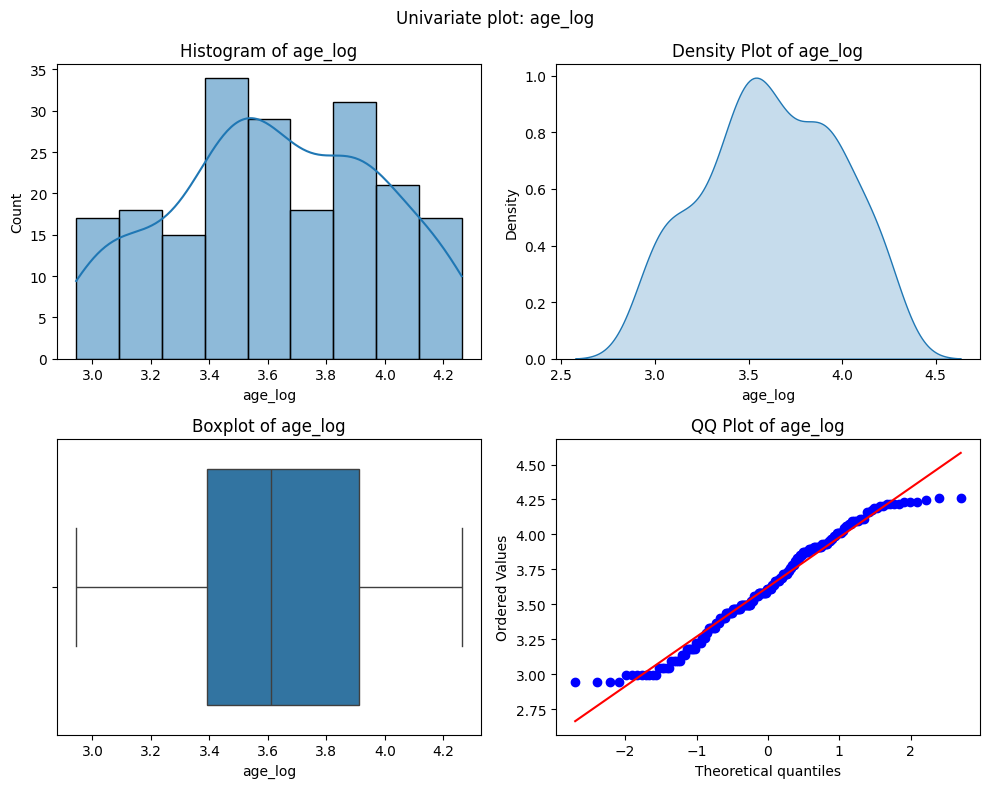

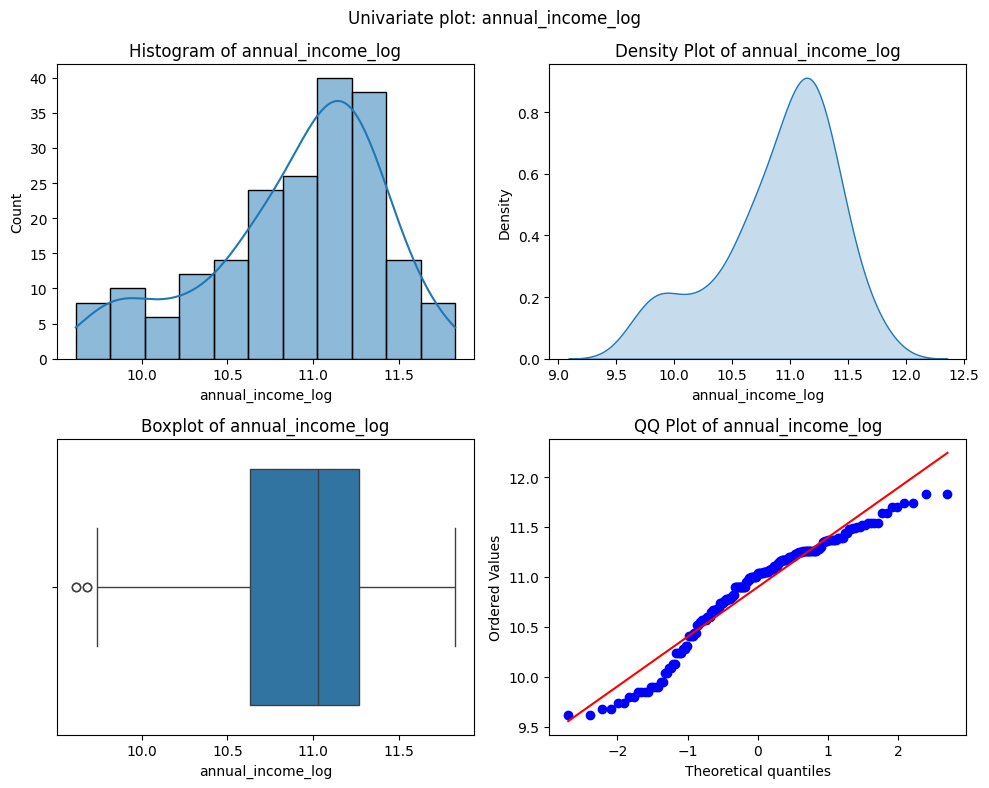

In [441]:
univariate_numerical_plots(df, 'age_log')
univariate_numerical_plots(df, 'annual_income_log')

In [442]:
result = get_shape_measures(df, ['age_log', 'annual_income_log'])
pd.DataFrame(result)

,age_log,annual_income_log
skew,-0.089491,-0.759604
skew_description,Slightly left-skewed,Moderately left-skewed
kurt,-0.884584,-0.055579
kurt_description,Very platykurtic(flat),Very platykurtic(flat)


- from the numerical and visualization we can confidently select `yeo-johnson` transformation

we need to remove `age`, `annual_income`, `age_log`, `annual_incomelog`

In [444]:
# One-hot encode Gender
encoder = OneHotEncoder(drop='first', sparse_output=False)
gender_encoded = encoder.fit_transform(df[['gender']])

# Get the column names from the encoder
gender_columns = encoder.get_feature_names_out()

# Create a DataFrame from the encoded data
gender_df = pd.DataFrame(gender_encoded, columns=gender_columns)

# Merge with original dataframe
df_encoded = pd.concat([df.drop('gender', axis=1), gender_df], axis=1)

---
___

# IV. Feature Engineering

---

## Feature Encoding

we have only one categorical feature in the data: 'gender', which is Nominal data
It is a type of categorical data where the categories do not have any inherent order or ranking.
- For nominal encoding, `One-Hot Encoding (OHE)` is a suitable choice.

In [445]:
# One-hot encode Gender
encoder = OneHotEncoder(drop='first', sparse_output=False)
gender_encoded = encoder.fit_transform(df[['gender']])
# gender_encode

In [446]:
# Get the column names from the encoder
gender_columns = encoder.get_feature_names_out()
gender_columns

array(['gender_Male'], dtype=object)

In [447]:
# Create a DataFrame from the encoded data
gender_df = pd.DataFrame(gender_encoded, columns=gender_columns)
gender_df.sample(5)

,gender_Male
109,1.0
105,0.0
6,0.0
112,0.0
154,0.0


In [448]:
# Merge with original dataframe
df = pd.concat([df.drop('gender', axis=1), gender_df], axis=1)
df

,age,annual_income,spending_score,age_transformed_yj,annual_income_transformed_yj,age_log,annual_income_log,gender_Male
0,19,15000,39,3.652141,797.534776,2.995732,9.615872,1.0
1,21,15000,81,3.792925,797.534776,3.091042,9.615872,1.0
2,20,16000,6,3.723995,831.782344,3.044522,9.680406,0.0
3,23,16000,77,3.922962,831.782344,3.178054,9.680406,0.0
4,31,17000,40,4.363368,865.288975,3.465736,9.741027,0.0
...,...,...,...,...,...,...,...,...
195,35,120000,79,4.548417,3087.627715,3.583519,11.695255,0.0
196,45,126000,28,4.942604,3187.210791,3.828641,11.744045,0.0
197,32,126000,74,4.411444,3187.210791,3.496508,11.744045,1.0
198,32,137000,18,4.411444,3365.579124,3.496508,11.827744,1.0


lets remove all redundent feature from df

In [449]:
df = df.drop(columns=['age', 'annual_income', 'age_log', 'annual_income_log'], axis=1)
df

,spending_score,age_transformed_yj,annual_income_transformed_yj,gender_Male
0,39,3.652141,797.534776,1.0
1,81,3.792925,797.534776,1.0
2,6,3.723995,831.782344,0.0
3,77,3.922962,831.782344,0.0
4,40,4.363368,865.288975,0.0
...,...,...,...,...
195,79,4.548417,3087.627715,0.0
196,28,4.942604,3187.210791,0.0
197,74,4.411444,3187.210791,1.0
198,18,4.411444,3365.579124,1.0


In [450]:
non_std_processed_customer_data_DBSCAN_version_03 = df.copy(deep=True)
# save both data versions to data_version directory
non_std_processed_customer_data_DBSCAN_version_03.to_csv(ROOT_DIR/'data'/'processed_data'/'non_std_processed_customer_data_DBSCAN_version_03.csv', index=False)

---

## Feature Scaling

Feature Scaling in Clustering
Feature scaling is crucial in clustering because it:

- Reduces dominance: Prevents features with large ranges from dominating the clustering process.
- Improves comparability: Enables comparison of features with different units or scales.
- Enhances interpretability: Facilitates understanding of cluster structures and relationships.


- If features are not scaled, the `annual_income` feature may dominate the clustering process due to its larger range. 
- However, if features are scaled (e.g., using standardization or normalization), both features will contribute equally to the clustering process, leading to more accurate and meaningful results.

In [451]:
df.columns

Index(['spending_score', 'age_transformed_yj', 'annual_income_transformed_yj',
       'gender_Male'],
      dtype='object')

In [452]:
scaler = StandardScaler()
num_features = ['spending_score', 'age_transformed_yj', 'annual_income_transformed_yj']
df[num_features] = scaler.fit_transform(df[num_features])


In [453]:
df

,spending_score,age_transformed_yj,annual_income_transformed_yj,gender_Male
0,-0.434801,-1.718993,-1.993334,1.0
1,1.195704,-1.470002,-1.993334,1.0
2,-1.715913,-1.591912,-1.933217,0.0
3,1.040418,-1.240020,-1.933217,0.0
4,-0.395980,-0.461118,-1.874401,0.0
...,...,...,...,...
195,1.118061,-0.133840,2.026598,0.0
196,-0.861839,0.563320,2.201402,0.0
197,0.923953,-0.376090,2.201402,1.0
198,-1.250054,-0.376090,2.514502,1.0


In [454]:
df

,spending_score,age_transformed_yj,annual_income_transformed_yj,gender_Male
0,-0.434801,-1.718993,-1.993334,1.0
1,1.195704,-1.470002,-1.993334,1.0
2,-1.715913,-1.591912,-1.933217,0.0
3,1.040418,-1.240020,-1.933217,0.0
4,-0.395980,-0.461118,-1.874401,0.0
...,...,...,...,...
195,1.118061,-0.133840,2.026598,0.0
196,-0.861839,0.563320,2.201402,0.0
197,0.923953,-0.376090,2.201402,1.0
198,-1.250054,-0.376090,2.514502,1.0


processed_customer_data_version_01.csv

In [455]:
processed_customer_data_version_01 = df.copy(deep=True)
# save both data versions to data_version directory
processed_customer_data_version_01.to_csv(ROOT_DIR/'data'/'processed_data'/'processed_customer_data_version_01.csv')


---

## Feature Creation

In [456]:
data_version02 = pd.read_csv(ROOT_DIR/'data'/'data_versions'/'customer_data_version_02.csv')
df_ = data_version02.copy(deep=True)
df_.head()

,gender,age,annual_income,spending_score
0,Male,19,15000,39
1,Male,21,15000,81
2,Female,20,16000,6
3,Female,23,16000,77
4,Female,31,17000,40


In [457]:
bin_labels = {
    (0, 18, 25, 40, 60, 100): ['teen', 'young_adult', 'adult', 'middle_age', 'seniors'], # binning for age
    (0, 15000, 41500, 78000, 110000): ['low-income', 'middle-income', 'high-income', 'affluent'], # binning for annual_income
    (0, 15000, 41500, 61500, 78000, 90000, 1200000): ['low-income', 'lower-middle-income', 'middle-income', 'upper-middle-income', 'high-income', 'affluent'], # binning for annual_income
    (0, 25, 50, 75, 100): ['low-spender', 'moderate-spender', 'high-spender', 'premium-spender']
}

# exmaple: get the bins and labales later for binning
first_bin = list(bin_labels.keys())[0]
first_labels = list(bin_labels.values())[0]
print(f"{first_bin} = {first_labels}")

(0, 18, 25, 40, 60, 100) = ['teen', 'young_adult', 'adult', 'middle_age', 'seniors']


Age Groups

In [458]:
df_['age_group'] = pd.cut(
    df_['age'],
    bins = list(bin_labels.keys())[0],
    labels = list(bin_labels.values())[0]
)

Income Level

In [459]:
df_['income_level'] = pd.cut(
    df_['annual_income'], 
    bins=list(bin_labels.keys())[1], 
    labels=list(bin_labels.values())[1])

Spending Score

In [460]:
df_['spending_behavior'] = pd.cut(
    df_['spending_score'],
    bins=list(bin_labels.keys())[3], 
    labels=list(bin_labels.values())[3]
)

In [461]:
df_

,gender,age,annual_income,spending_score,age_group,income_level,spending_behavior
0,Male,19,15000,39,young_adult,low-income,moderate-spender
1,Male,21,15000,81,young_adult,low-income,premium-spender
2,Female,20,16000,6,young_adult,middle-income,low-spender
3,Female,23,16000,77,young_adult,middle-income,premium-spender
4,Female,31,17000,40,adult,middle-income,moderate-spender
...,...,...,...,...,...,...,...
195,Female,35,120000,79,adult,NaN,premium-spender
196,Female,45,126000,28,middle_age,NaN,moderate-spender
197,Male,32,126000,74,adult,NaN,high-spender
198,Male,32,137000,18,adult,NaN,low-spender


In [462]:
# # Group by age_group and calculate the 75th percentile of annual_income
# percentiles = df.groupby('age_group')['annual_income'].quantile(0.75)

# # Map the percentiles to the original DataFrame
# df['high_income_threshold'] = df['age_group'].map(percentiles)

# # Create a new feature indicating high buying power
# df['high_buying_power'] = df['annual_income'] > df['high_income_threshold']

In [463]:
df_

,gender,age,annual_income,spending_score,age_group,income_level,spending_behavior
0,Male,19,15000,39,young_adult,low-income,moderate-spender
1,Male,21,15000,81,young_adult,low-income,premium-spender
2,Female,20,16000,6,young_adult,middle-income,low-spender
3,Female,23,16000,77,young_adult,middle-income,premium-spender
4,Female,31,17000,40,adult,middle-income,moderate-spender
...,...,...,...,...,...,...,...
195,Female,35,120000,79,adult,NaN,premium-spender
196,Female,45,126000,28,middle_age,NaN,moderate-spender
197,Male,32,126000,74,adult,NaN,high-spender
198,Male,32,137000,18,adult,NaN,low-spender


#### **Buying Power Feature**
The newly created feature, "buying_power," categorizes customers into three groups based on their annual income relative to their age group's income distribution:

Categories:
1. High Buying Power: Customers with an annual income above the 75th percentile of their age group's income distribution. These individuals have a higher purchasing power compared to their peers.
2. Moderate Buying Power: Customers with an annual income between the 25th and 75th percentiles of their age group's income distribution. These individuals have a moderate purchasing power compared to their peers.
3. Low Buying Power: Customers with an annual income below the 25th percentile of their age group's income distribution. These individuals have a lower purchasing power compared to their peers.

Purpose:
The "buying_power" feature helps businesses understand their customers' purchasing capabilities and tailor their marketing strategies, product offerings, and pricing accordingly. By segmenting customers based on their buying power, businesses can:

- Target high-value customers with premium products or services
- Offer competitive pricing and promotions to moderate buying power customers
- Provide affordable options and discounts to low buying power customers

Benefits:
1. Improved Customer Segmentation: The "buying_power" feature enables businesses to segment their customers more effectively, leading to targeted marketing and improved customer satisfaction.
2. Enhanced Pricing Strategies: By understanding customers' purchasing power, businesses can develop pricing strategies that balance revenue goals with customer affordability.
3. Increased Customer Loyalty: By catering to customers' buying power, businesses can build stronger relationships, increase customer loyalty, and drive long-term growth.

In [464]:
# Group by age_group and calculate the percentiles of annual_income
percentiles = df_.groupby('age_group')['annual_income'].quantile([0.25, 0.75])

# Map the percentiles to the original DataFrame
df_['25th_percentile'] = df_['age_group'].map(percentiles.xs(0.25, level=1))
df_['75th_percentile'] = df_['age_group'].map(percentiles.xs(0.75, level=1))

# Create a new feature indicating buying power
df_['buying_power'] = df_.apply(
    lambda row: 'High Buying Power' if row['annual_income'] > row['75th_percentile'] 
                                else 'Moderate Buying Power' if row['annual_income'] > row['25th_percentile'] 
                                else 'Low Buying Power', axis=1)

In [465]:
df_

,gender,age,annual_income,spending_score,age_group,income_level,spending_behavior,25th_percentile,75th_percentile,buying_power
0,Male,19,15000,39,young_adult,low-income,moderate-spender,21750.0,62750.0,Low Buying Power
1,Male,21,15000,81,young_adult,low-income,premium-spender,21750.0,62750.0,Low Buying Power
2,Female,20,16000,6,young_adult,middle-income,low-spender,21750.0,62750.0,Low Buying Power
3,Female,23,16000,77,young_adult,middle-income,premium-spender,21750.0,62750.0,Low Buying Power
4,Female,31,17000,40,adult,middle-income,moderate-spender,47500.0,87000.0,Low Buying Power
...,...,...,...,...,...,...,...,...,...,...
195,Female,35,120000,79,adult,NaN,premium-spender,47500.0,87000.0,High Buying Power
196,Female,45,126000,28,middle_age,NaN,moderate-spender,43000.0,77000.0,High Buying Power
197,Male,32,126000,74,adult,NaN,high-spender,47500.0,87000.0,High Buying Power
198,Male,32,137000,18,adult,NaN,low-spender,47500.0,87000.0,High Buying Power


In [466]:
df_['buying_power'].unique()

array(['Low Buying Power', 'Moderate Buying Power', 'High Buying Power'],
      dtype=object)

In [467]:
df_['spending_behavior'].unique()

['moderate-spender', 'premium-spender', 'low-spender', 'high-spender']
Categories (4, object): ['low-spender' < 'moderate-spender' < 'high-spender' < 'premium-spender']

#### Comparing `Buying Power` and `Spending Behavior`
To flag customers who may default or delay payment in case of EMI purchases, we can create a new feature that combines "buying_power" and "spending_behavior." Here's a suggested approach:

Categories:
We can create a new feature called "credit_risk" with the following categories:

- Low Risk: High Buying Power and Premium Spender or High Spender
- Moderate Risk: Moderate Buying Power and Moderate Spender
- High Risk: Low Buying Power and Low Spender or Moderate Spender
- Very High Risk: Low Buying Power and Premium Spender or High Spender

Rationale:
- Customers with high buying power and premium spending behavior are likely to be low-risk borrowers.
- Customers with moderate buying power and moderate spending behavior are likely to be moderate-risk borrowers.
- Customers with low buying power and low spending behavior are likely to be high-risk borrowers.
- Customers with low buying power and premium spending behavior are likely to be very high-risk borrowers, as they may be over-extending themselves.

This updated feature can help businesses identify positive customers who exhibit stable and mature spending behavior, allowing them to focus on nurturing these relationships and providing targeted marketing efforts.

In [468]:

# Create a new feature called "credit_risk"
df_['credit_risk'] = df_.apply(lambda row: 'Low Risk' if row['buying_power'] == 'High Buying Power' and row['spending_behavior'] in ['premium-spender', 'high-spender']
                                else 'Moderate Risk' if row['buying_power'] == 'Moderate Buying Power' and row['spending_behavior'] == 'moderate-spender'
                                else 'High Risk' if row['buying_power'] == 'Low Buying Power' and row['spending_behavior'] in ['low-spender', 'moderate-spender']
                                else 'Very High Risk' if row['buying_power'] == 'Low Buying Power' and row['spending_behavior'] in ['premium-spender', 'high-spender']
                                else 'Unknown', axis=1)

In [469]:
df_

,gender,age,annual_income,spending_score,age_group,income_level,spending_behavior,25th_percentile,75th_percentile,buying_power,credit_risk
0,Male,19,15000,39,young_adult,low-income,moderate-spender,21750.0,62750.0,Low Buying Power,High Risk
1,Male,21,15000,81,young_adult,low-income,premium-spender,21750.0,62750.0,Low Buying Power,Very High Risk
2,Female,20,16000,6,young_adult,middle-income,low-spender,21750.0,62750.0,Low Buying Power,High Risk
3,Female,23,16000,77,young_adult,middle-income,premium-spender,21750.0,62750.0,Low Buying Power,Very High Risk
4,Female,31,17000,40,adult,middle-income,moderate-spender,47500.0,87000.0,Low Buying Power,High Risk
...,...,...,...,...,...,...,...,...,...,...,...
195,Female,35,120000,79,adult,NaN,premium-spender,47500.0,87000.0,High Buying Power,Low Risk
196,Female,45,126000,28,middle_age,NaN,moderate-spender,43000.0,77000.0,High Buying Power,Unknown
197,Male,32,126000,74,adult,NaN,high-spender,47500.0,87000.0,High Buying Power,Low Risk
198,Male,32,137000,18,adult,NaN,low-spender,47500.0,87000.0,High Buying Power,Unknown


## Creating an "Opportunity" Feature

Creating an "Opportunity" Feature
We can create a new feature called "opportunity" to flag positive customers who exhibit a stable and mature spending behavior. Here's an approach:

Categories:
We can create the following categories for the "opportunity" feature:

- High Opportunity: High Buying Power and Moderate Spender or Low Spender
- Moderate Opportunity: Moderate Buying Power and Low Spender
- Low Opportunity: Low Buying Power and any spending behavior
- Very High Opportunity: High Buying Power and Premium Spender or High Spender (indicating a high potential for upselling or cross-selling)

Rationale:
- Customers with high buying power and moderate or low spending behavior are likely to be high-opportunity customers, as they have a stable financial situation and are less likely to over-extend themselves.
- Customers with moderate buying power and low spending behavior are likely to be moderate-opportunity customers, as they have a conservative spending approach and are more likely to prioritize saving and debt repayment.
- Customers with low buying power are likely to be low-opportunity customers, as they may have limited financial resources and may not be able to afford premium products or services.

This new feature can help businesses identify high-opportunity customers who exhibit stable and mature spending behavior, allowing them to focus on nurturing these relationships and providing targeted marketing efforts.

In [470]:

# Create a new feature called "opportunity"
df_['opportunity'] = df_.apply(lambda row: 'High Opportunity' if row['buying_power'] == 'High Buying Power' and row['spending_behavior'] in ['moderate-spender', 'low-spender']
                                else 'Moderate Opportunity' if row['buying_power'] == 'Moderate Buying Power' and row['spending_behavior'] == 'low-spender'
                                else 'Low Opportunity' if row['buying_power'] == 'Low Buying Power'
                                else 'Very High Opportunity' if row['buying_power'] == 'High Buying Power' and row['spending_behavior'] in ['premium-spender', 'high-spender']
                                else 'Unknown', axis=1)

In [471]:
df_

,gender,age,annual_income,spending_score,age_group,income_level,spending_behavior,25th_percentile,75th_percentile,buying_power,credit_risk,opportunity
0,Male,19,15000,39,young_adult,low-income,moderate-spender,21750.0,62750.0,Low Buying Power,High Risk,Low Opportunity
1,Male,21,15000,81,young_adult,low-income,premium-spender,21750.0,62750.0,Low Buying Power,Very High Risk,Low Opportunity
2,Female,20,16000,6,young_adult,middle-income,low-spender,21750.0,62750.0,Low Buying Power,High Risk,Low Opportunity
3,Female,23,16000,77,young_adult,middle-income,premium-spender,21750.0,62750.0,Low Buying Power,Very High Risk,Low Opportunity
4,Female,31,17000,40,adult,middle-income,moderate-spender,47500.0,87000.0,Low Buying Power,High Risk,Low Opportunity
...,...,...,...,...,...,...,...,...,...,...,...,...
195,Female,35,120000,79,adult,NaN,premium-spender,47500.0,87000.0,High Buying Power,Low Risk,Very High Opportunity
196,Female,45,126000,28,middle_age,NaN,moderate-spender,43000.0,77000.0,High Buying Power,Unknown,High Opportunity
197,Male,32,126000,74,adult,NaN,high-spender,47500.0,87000.0,High Buying Power,Low Risk,Very High Opportunity
198,Male,32,137000,18,adult,NaN,low-spender,47500.0,87000.0,High Buying Power,Unknown,High Opportunity


#### Applying the 80/20 Principle
e can apply the 80/20 principle to the "spending_score" feature to identify the top 20% of customers who generate 80% of the spending.

This analysis can help businesses identify the characteristics of the top 20% of customers who generate 80% of the spending, allowing them to focus on nurturing these relationships and providing targeted marketing efforts.

Insights:
- What is the distribution of buying power among the top 20% of customers?
- What is the distribution of spending behavior among the top 20% of customers?
- What is the distribution of credit risk among the top 20% of customers?
- What is the distribution of opportunity among the top 20% of customers?

In [472]:
# Calculate the total spending score
total_spending_score = df_['spending_score'].sum()

# Calculate the cumulative spending score
df_['cumulative_spending_score'] = df_['spending_score'].cumsum()

# Calculate the percentage of total spending score
df_['percentage_of_total_spending_score'] = (df_['cumulative_spending_score'] / total_spending_score) * 100

# Identify the top 20% of customers who generate 80% of the spending
top_20_percent = df_[df_['percentage_of_total_spending_score'] <= 80]

# Analyze the characteristics of the top 20% of customers
print(top_20_percent['buying_power'].value_counts())
print(top_20_percent['spending_behavior'].value_counts())
print(top_20_percent['credit_risk'].value_counts())
print(top_20_percent['opportunity'].value_counts())



buying_power
Moderate Buying Power    95
Low Buying Power         52
High Buying Power        13
Name: count, dtype: int64
spending_behavior
moderate-spender    58
high-spender        52
low-spender         25
premium-spender     25
Name: count, dtype: int64
credit_risk
Unknown           72
Moderate Risk     35
High Risk         29
Very High Risk    23
Low Risk           1
Name: count, dtype: int64
opportunity
Unknown                  88
Low Opportunity          52
High Opportunity         12
Moderate Opportunity      7
Very High Opportunity     1
Name: count, dtype: int64


In [473]:
df_

,gender,age,annual_income,spending_score,age_group,income_level,spending_behavior,25th_percentile,75th_percentile,buying_power,credit_risk,opportunity,cumulative_spending_score,percentage_of_total_spending_score
0,Male,19,15000,39,young_adult,low-income,moderate-spender,21750.0,62750.0,Low Buying Power,High Risk,Low Opportunity,39,0.388446
1,Male,21,15000,81,young_adult,low-income,premium-spender,21750.0,62750.0,Low Buying Power,Very High Risk,Low Opportunity,120,1.195219
2,Female,20,16000,6,young_adult,middle-income,low-spender,21750.0,62750.0,Low Buying Power,High Risk,Low Opportunity,126,1.254980
3,Female,23,16000,77,young_adult,middle-income,premium-spender,21750.0,62750.0,Low Buying Power,Very High Risk,Low Opportunity,203,2.021912
4,Female,31,17000,40,adult,middle-income,moderate-spender,47500.0,87000.0,Low Buying Power,High Risk,Low Opportunity,243,2.420319
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,Female,35,120000,79,adult,NaN,premium-spender,47500.0,87000.0,High Buying Power,Low Risk,Very High Opportunity,9837,97.978088
196,Female,45,126000,28,middle_age,NaN,moderate-spender,43000.0,77000.0,High Buying Power,Unknown,High Opportunity,9865,98.256972
197,Male,32,126000,74,adult,NaN,high-spender,47500.0,87000.0,High Buying Power,Low Risk,Very High Opportunity,9939,98.994024
198,Male,32,137000,18,adult,NaN,low-spender,47500.0,87000.0,High Buying Power,Unknown,High Opportunity,9957,99.173307


In [474]:
df_.shape

(200, 14)

In [475]:
df_.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 14 columns):
 #   Column                              Non-Null Count  Dtype   
---  ------                              --------------  -----   
 0   gender                              200 non-null    object  
 1   age                                 200 non-null    int64   
 2   annual_income                       200 non-null    int64   
 3   spending_score                      200 non-null    int64   
 4   age_group                           200 non-null    category
 5   income_level                        192 non-null    category
 6   spending_behavior                   200 non-null    category
 7   25th_percentile                     200 non-null    category
 8   75th_percentile                     200 non-null    category
 9   buying_power                        200 non-null    object  
 10  credit_risk                         200 non-null    object  
 11  opportunity                     

In [476]:
to_remove_from_df_ = ['Unnamed: 0', '25th_percentile', '75th_percentile', 'cumulative_spending_score' ]
df_ = df_.drop(columns=to_remove_from_df_, axis=1)

KeyError: "['Unnamed: 0'] not found in axis"

In [ ]:
customer_data_version_03 = df_.copy(deep=True)
# customer_data_version_02 = data.copy(deep=True)

# save both data versions to data_version directory
customer_data_version_03.to_csv(ROOT_DIR/'data'/'data_versions'/'feature-rich_customer_data_version_03.csv')
# customer_data_version_02.to_csv(ROOT_DIR/'data'/'data_versions'/'customer_data_version_02.csv')

---

### Feature engineering of `customer_data_version_03`

In [ ]:
df_

,gender,age,annual_income,spending_score,age_group,income_level,spending_behavior,buying_power,credit_risk,opportunity,percentage_of_total_spending_score
0,Male,19,15000,39,young_adult,low-income,moderate-spender,Low Buying Power,High Risk,Low Opportunity,0.388446
1,Male,21,15000,81,young_adult,low-income,premium-spender,Low Buying Power,Very High Risk,Low Opportunity,1.195219
2,Female,20,16000,6,young_adult,middle-income,low-spender,Low Buying Power,High Risk,Low Opportunity,1.254980
3,Female,23,16000,77,young_adult,middle-income,premium-spender,Low Buying Power,Very High Risk,Low Opportunity,2.021912
4,Female,31,17000,40,adult,middle-income,moderate-spender,Low Buying Power,High Risk,Low Opportunity,2.420319
...,...,...,...,...,...,...,...,...,...,...,...
195,Female,35,120000,79,adult,NaN,premium-spender,High Buying Power,Low Risk,Very High Opportunity,97.978088
196,Female,45,126000,28,middle_age,NaN,moderate-spender,High Buying Power,Unknown,High Opportunity,98.256972
197,Male,32,126000,74,adult,NaN,high-spender,High Buying Power,Low Risk,Very High Opportunity,98.994024
198,Male,32,137000,18,adult,NaN,low-spender,High Buying Power,Unknown,High Opportunity,99.173307


In [ ]:
df_.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   Column                              Non-Null Count  Dtype   
---  ------                              --------------  -----   
 0   gender                              200 non-null    object  
 1   age                                 200 non-null    int64   
 2   annual_income                       200 non-null    int64   
 3   spending_score                      200 non-null    int64   
 4   age_group                           200 non-null    category
 5   income_level                        192 non-null    category
 6   spending_behavior                   200 non-null    category
 7   buying_power                        200 non-null    object  
 8   credit_risk                         200 non-null    object  
 9   opportunity                         200 non-null    object  
 10  percentage_of_total_spending_score  200 non-null    float64 
dtypes: category(3), float64(1), int6

In [ ]:
num_features = df_.select_dtypes(include=['int64', 'float64']).columns
norm_features = ['gender', 'age_group']
ord_features = ['income_level', 'spending_behavior', 'buying_power', 'credit_risk', 'opportunity']

In [ ]:
num_features

Index(['age', 'annual_income', 'spending_score',
       'percentage_of_total_spending_score'],
      dtype='object')

In [ ]:
norm_features

['gender', 'age_group']

In [ ]:
ord_features

['income_level',
 'spending_behavior',
 'buying_power',
 'credit_risk',
 'opportunity']

In [ ]:
len(df_.columns) == len(num_features) + len(norm_features) + len(ord_features)

True


#### Feature Categorization and Encoding
I've categorized the features into:

1. Numerical Features (num_features): These are continuous features that can take any numerical value.
2. Nominal Features (norm_features): These are categorical features with no inherent order or ranking within their labels.
3. Ordinal Features (ord_features): These are categorical features with an inherent order or ranking within their labels.

Encoding:
1. Nominal Features: Use One-Hot Encoding (OHE) to transform these features into numerical representations.
2. Ordinal Features: Use Ordinal Encoding to transform these features into numerical representations, preserving their inherent order.

In [ ]:

# One-Hot Encoding for nominal features
ohe = OneHotEncoder(handle_unknown='ignore')
norm_features_encoded = ohe.fit_transform(df_[norm_features])

# Ordinal Encoding for ordinal features
oe = OrdinalEncoder()
ord_features_encoded = oe.fit_transform(df_[ord_features])

Benefits:
1. Improved Model Performance: Encoding categorical features can improve the performance of machine learning models.
2. Data Consistency: Encoding ensures that categorical features are represented consistently across the dataset.

Next Steps:
1. Combine Encoded Features: Combine the encoded nominal and ordinal features with the numerical features.

In [ ]:
# Yeo-Johnson transformation for numerical features
pt = PowerTransformer(method='yeo-johnson')
num_features_transformed = pt.fit_transform(df_[num_features])

In [ ]:
num_features_transformed

array([[-1.71899306e+00, -1.99333421e+00, -3.85307505e-01,
        -2.06073706e+00],
       [-1.47000195e+00, -1.99333421e+00,  1.16446697e+00,
        -1.99298666e+00],
       [-1.59191222e+00, -1.93321748e+00, -1.82042446e+00,
        -1.98827724e+00],
       [-1.24001951e+00, -1.93321748e+00,  1.02354921e+00,
        -1.93057724e+00],
       [-4.61117951e-01, -1.87440135e+00, -3.46102672e-01,
        -1.90225814e+00],
       [-1.35283061e+00, -1.87440135e+00,  9.88144263e-01,
        -1.85085691e+00],
       [-1.33839588e-01, -1.81678352e+00, -1.82042446e+00,
        -1.84691539e+00],
       [-1.24001951e+00, -1.81678352e+00,  1.61530777e+00,
        -1.78703006e+00],
       [ 1.58465719e+00, -1.76027490e+00, -1.98173773e+00,
        -1.78517141e+00],
       [-5.48494472e-01, -1.76027490e+00,  8.45790231e-01,
        -1.74141116e+00],
       [ 1.72131344e+00, -1.76027490e+00, -1.43390799e+00,
        -1.73307879e+00],
       [-1.33839588e-01, -1.76027490e+00,  1.78606543e+00,
      

In [ ]:
# Yeo-Johnson transformation for numerical features
pt = PowerTransformer(method='yeo-johnson')
num_features_transformed = pt.fit_transform(df_[num_features])

# Standard scaling for numerical features
scaler = StandardScaler()
num_features_scaled = scaler.fit_transform(num_features_transformed)

In [ ]:
# Convert encoded nominal features to DataFrame
norm_features_encoded_df = pd.DataFrame(norm_features_encoded, columns=ohe.get_feature_names_out())

# Convert encoded ordinal features to DataFrame
ord_features_encoded_df = pd.DataFrame(ord_features_encoded, columns=ord_features)

# Convert scaled numerical features to DataFrame
num_features_scaled_df = pd.DataFrame(num_features_scaled, columns=num_features)

# Concatenate all DataFrames
df_transformed = pd.concat([norm_features_encoded_df, ord_features_encoded_df, num_features_scaled_df], axis=1)

---
---

## Feature Selection

---

---
___

# V. Modeling

In [ ]:
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [ ]:
df

,spending_score,age_transformed_yj,annual_income_transformed_yj,gender_Male
0,-0.434801,-1.718993,-1.993334,1.0
1,1.195704,-1.470002,-1.993334,1.0
2,-1.715913,-1.591912,-1.933217,0.0
3,1.040418,-1.240020,-1.933217,0.0
4,-0.395980,-0.461118,-1.874401,0.0
...,...,...,...,...
195,1.118061,-0.133840,2.026598,0.0
196,-0.861839,0.563320,2.201402,0.0
197,0.923953,-0.376090,2.201402,1.0
198,-1.250054,-0.376090,2.514502,1.0


In [ ]:


# Assuming df is your dataframe
X = df.values  

# Function to evaluate clustering
def evaluate_clustering(X, labels, name):
    if len(set(labels)) > 1 and -1 not in set(labels):  # avoid invalid scores
        sil = silhouette_score(X, labels)
        db = davies_bouldin_score(X, labels)
    else:
        sil, db = None, None
    print(f"{name}:")
    print(f"   Clusters: {len(set(labels))}")
    print(f"   Silhouette Score: {sil}")
    print(f"   Davies-Bouldin Score: {db}\n")
    return {"algorithm": name, "clusters": len(set(labels)), "silhouette": sil, "db": db}

results = []

# 1. KMeans
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X)
results.append(evaluate_clustering(X, labels, "KMeans"))

# 2. Agglomerative Clustering
agg = AgglomerativeClustering(n_clusters=5)
labels = agg.fit_predict(X)
results.append(evaluate_clustering(X, labels, "Agglomerative"))

# 3. DBSCAN
dbscan = DBSCAN(eps=0.8, min_samples=5)
labels = dbscan.fit_predict(X)
results.append(evaluate_clustering(X, labels, "DBSCAN"))

# 4. Gaussian Mixture Model (GMM)
gmm = GaussianMixture(n_components=5, random_state=42)
labels = gmm.fit_predict(X)
results.append(evaluate_clustering(X, labels, "Gaussian Mixture"))

# 5. Spectral Clustering
spectral = SpectralClustering(n_clusters=5, affinity='nearest_neighbors', random_state=42)
labels = spectral.fit_predict(X)
results.append(evaluate_clustering(X, labels, "Spectral Clustering"))

# Collect results
results_df = pd.DataFrame(results)
print(results_df)


KMeans:
   Clusters: 5
   Silhouette Score: 0.3627126097041005
   Davies-Bouldin Score: 1.043534613088189

Agglomerative:
   Clusters: 5
   Silhouette Score: 0.35039291343805246
   Davies-Bouldin Score: 1.0052277437212744

DBSCAN:
   Clusters: 7
   Silhouette Score: None
   Davies-Bouldin Score: None

Gaussian Mixture:
   Clusters: 5
   Silhouette Score: 0.31996369980231326
   Davies-Bouldin Score: 1.1287096596349666

Spectral Clustering:
   Clusters: 5
   Silhouette Score: 0.28968559892554396
   Davies-Bouldin Score: 1.2349662261953656

             algorithm  clusters  silhouette        db
0               KMeans         5    0.362713  1.043535
1        Agglomerative         5    0.350393  1.005228
2               DBSCAN         7         NaN       NaN
3     Gaussian Mixture         5    0.319964  1.128710
4  Spectral Clustering         5    0.289686  1.234966


In [ ]:
results_df

,algorithm,clusters,silhouette,db
0,KMeans,5,0.362713,1.043535
1,Agglomerative,5,0.350393,1.005228
2,DBSCAN,7,NaN,NaN
3,Gaussian Mixture,5,0.319964,1.128710
4,Spectral Clustering,5,0.289686,1.234966


KMeans and Agglomerative are your best baseline performers.

KMeans gives the highest Silhouette (0.363) → clusters are relatively well-separated.

Agglomerative gives the lowest DB score (1.005) → clusters are compact and distinct.

Gaussian Mixture and Spectral Clustering are weaker on both metrics.

DBSCAN didn’t work well here (likely because your data is relatively uniform & scaled, DBSCAN struggles unless there’s clear density structure).

So, as a baseline algorithm, I’d recommend KMeans (if interpretability and speed are priorities) or Agglomerative (if you want hierarchy and slightly better compactness).

lets try dbSCAN in non standardized data

In [ ]:
db_scan_data_01 = pd.read_csv(ROOT_DIR /'data' / 'processed_data'/'non_std_processed_customer_data_DBSCAN_version_03.csv')
X_dbscan_01 = db_scan_data_01.values

In [ ]:
# 3. DBSCAN
dbscan = DBSCAN(eps=0., min_samples=8)
labels = dbscan.fit_predict(X_dbscan_01)

evaluate_clustering(X, labels, "DBSCAN")

DBSCAN:
   Clusters: 1
   Silhouette Score: None
   Davies-Bouldin Score: None



{'algorithm': 'DBSCAN', 'clusters': 1, 'silhouette': None, 'db': None}

#### KMeans vs Agglomerative in 2D using PCA

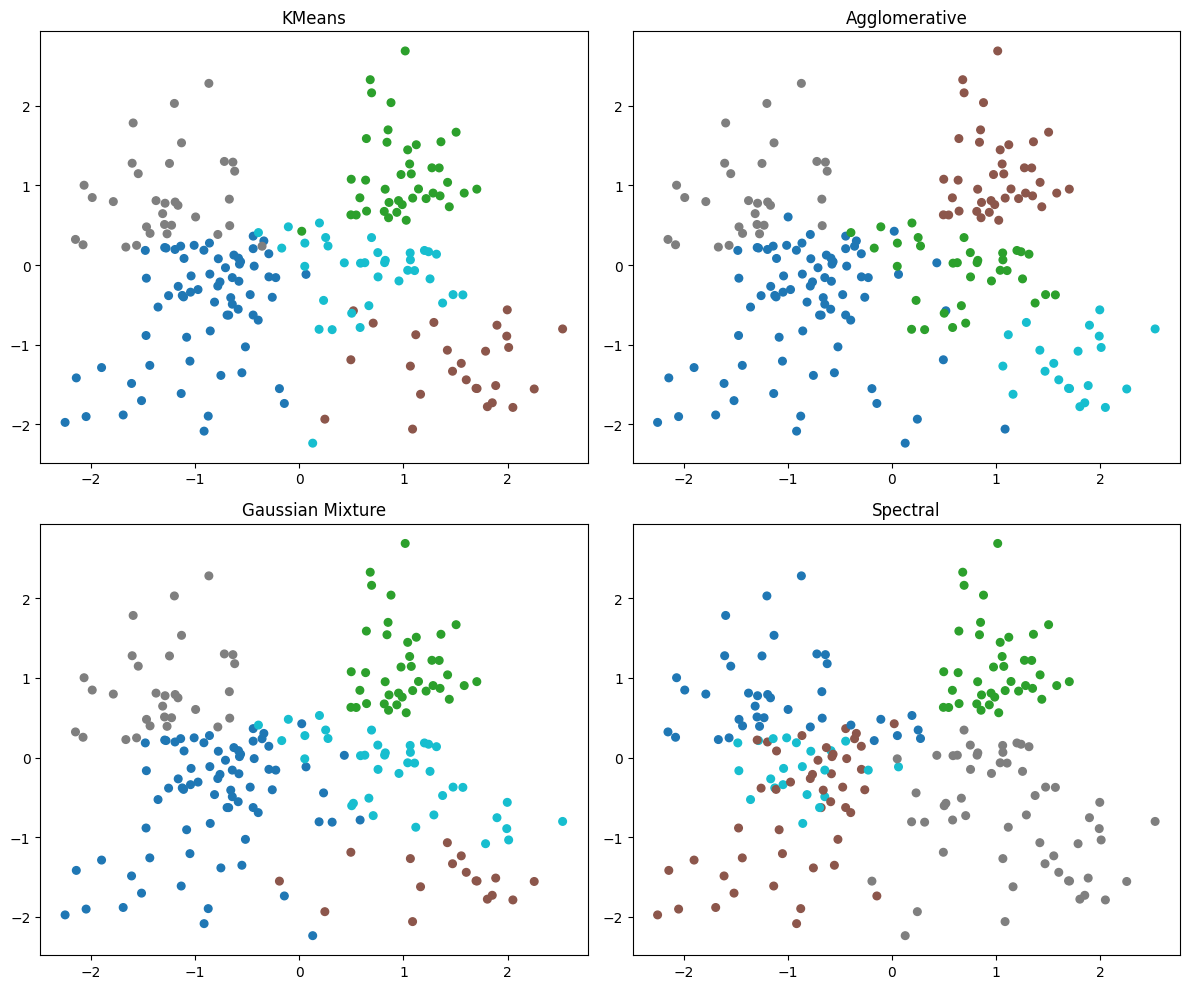

In [ ]:



X_ = df.values
X = X_.copy()

# Run clustering algorithms with 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42).fit(X)
agg = AgglomerativeClustering(n_clusters=5).fit(X)
gmm = GaussianMixture(n_components=5, random_state=42).fit(X)
spectral = SpectralClustering(n_clusters=5, affinity='nearest_neighbors', random_state=42).fit(X)

labels_dict = {
    "KMeans": kmeans.labels_,
    "Agglomerative": agg.labels_,
    "Gaussian Mixture": gmm.predict(X),
    "Spectral": spectral.labels_
}

# Reduce to 2D with PCA (faster than t-SNE for demo)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Plot clusters for each algorithm
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (name, labels) in zip(axes, labels_dict.items()):
    ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', s=30)
    ax.set_title(name)

plt.tight_layout()
plt.show()


#### KMeans vs Agglomerative in 2D using t-SNE

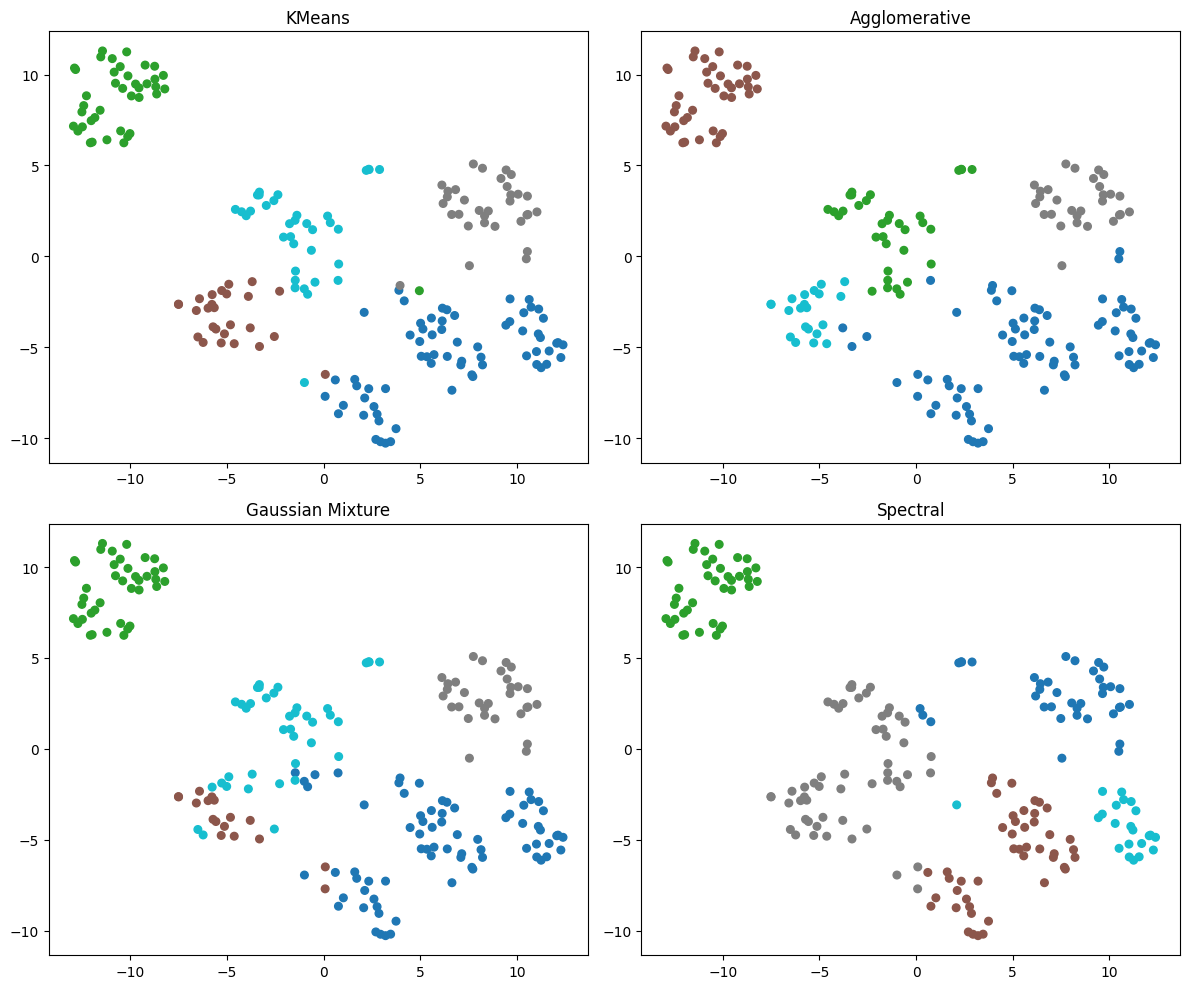

In [ ]:


# Assume df is your DataFrame
X = df.values.copy()

# Run clustering algorithms with 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42).fit(X)
agg = AgglomerativeClustering(n_clusters=5).fit(X)
gmm = GaussianMixture(n_components=5, random_state=42).fit(X)
spectral = SpectralClustering(n_clusters=5, affinity='nearest_neighbors', random_state=42).fit(X)

labels_dict = {
    "KMeans": kmeans.labels_,
    "Agglomerative": agg.labels_,
    "Gaussian Mixture": gmm.predict(X),
    "Spectral": spectral.labels_
}

# Reduce to 2D with t-SNE (slower than PCA but often gives better cluster separation)
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X)

# Plot clusters for each algorithm
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (name, labels) in zip(axes, labels_dict.items()):
    scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='tab10', s=30)
    ax.set_title(name)
    
plt.tight_layout()
plt.show()


### overlay KMeans and Agglomerative clusters 

This way, you can directly compare how the same points are clustered differently by each algorithm.

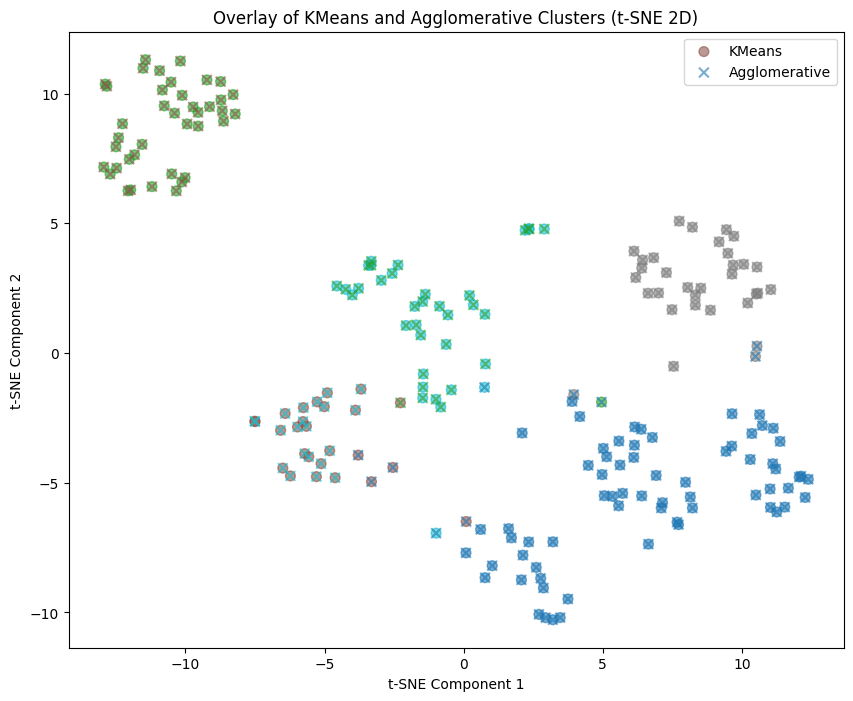

In [ ]:

X = df.values.copy()

# Run clustering algorithms with 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42).fit(X)
agg = AgglomerativeClustering(n_clusters=5).fit(X)

# t-SNE for 2D embedding
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X)

# Overlay KMeans and Agglomerative clusters
plt.figure(figsize=(10, 8))

# KMeans: circles
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=kmeans.labels_, cmap='tab10', s=50, alpha=0.6, label='KMeans', marker='o')

# Agglomerative: crosses
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=agg.labels_, cmap='tab10', s=50, alpha=0.6, label='Agglomerative', marker='x')

plt.title("Overlay of KMeans and Agglomerative Clusters (t-SNE 2D)")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(["KMeans", "Agglomerative"])
plt.show()


- Circles (`o`) represent KMeans clusters, 
- crosses (`x`) represent Agglomerative clusters.

We can assign distinct color pairs to each cluster from KMeans and Agglomerative so that overlapping clusters are visually clear, and mismatches really stand out

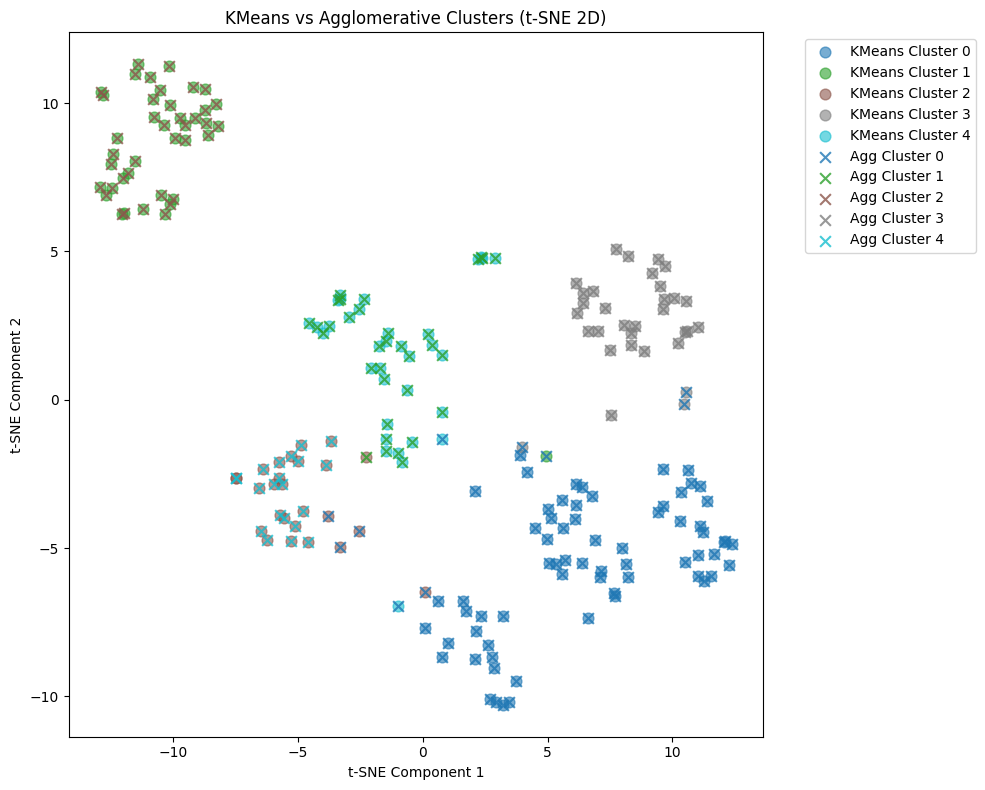

In [ ]:


X = df.values.copy()

# Run clustering algorithms with 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42).fit(X)
agg = AgglomerativeClustering(n_clusters=5).fit(X)

# t-SNE 2D embedding
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X)

# Define unique color palette for 5 clusters
colors = plt.cm.tab10(np.linspace(0, 1, 5))

plt.figure(figsize=(10, 8))

# Plot KMeans clusters
for i in range(5):
    plt.scatter(X_tsne[kmeans.labels_ == i, 0], X_tsne[kmeans.labels_ == i, 1],
                c=[colors[i]], marker='o', s=60, alpha=0.6, label=f'KMeans Cluster {i}')

# Plot Agglomerative clusters with same colors but different marker
for i in range(5):
    plt.scatter(X_tsne[agg.labels_ == i, 0], X_tsne[agg.labels_ == i, 1],
                c=[colors[i]], marker='x', s=60, alpha=0.8, label=f'Agg Cluster {i}')

plt.title("KMeans vs Agglomerative Clusters (t-SNE 2D)")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


🔹 What this does:

Each cluster from KMeans and Agglomerative gets a unique color, but different markers (o for KMeans, x for Agglomerative).

You can easily spot where clusters align and where they differ.

alpha lets overlapping points be semi-transparent, improving visibility.

The legend is extended outside the plot to keep things neat.

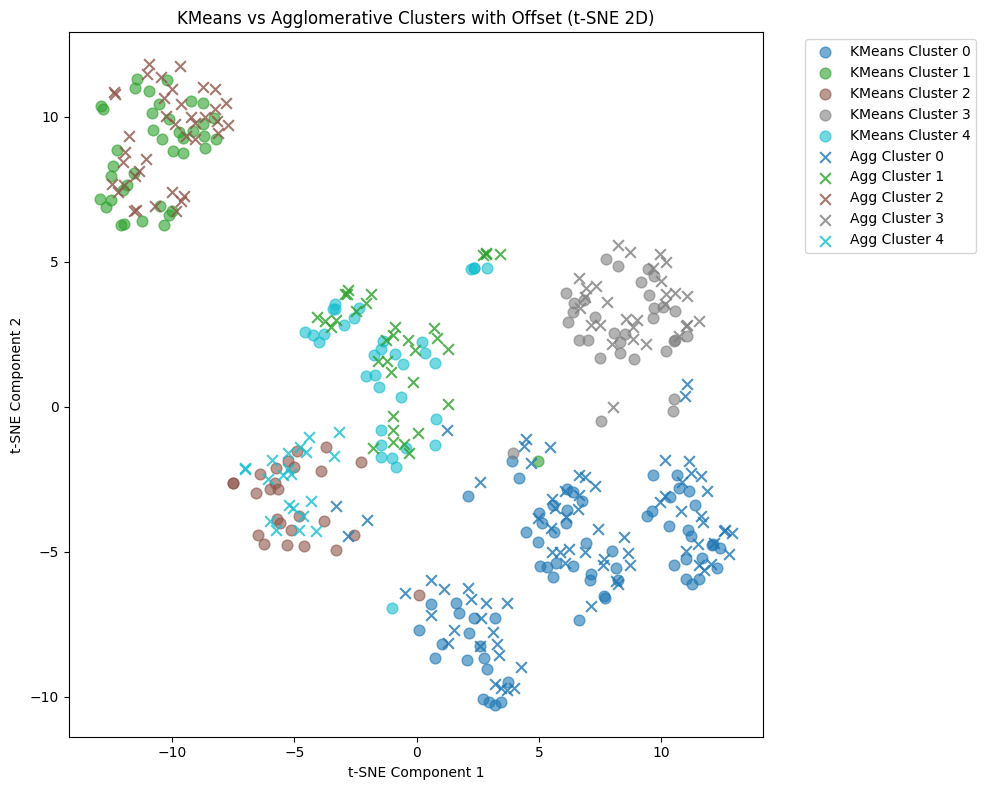

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering

X = df.values.copy()

# Run clustering algorithms with 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42).fit(X)
agg = AgglomerativeClustering(n_clusters=5).fit(X)

# t-SNE 2D embedding
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X)

# Define unique color palette for 5 clusters
colors = plt.cm.tab10(np.linspace(0, 1, 5))

# Small offset for Agglomerative points
offset = 0.5

plt.figure(figsize=(10, 8))

# Plot KMeans clusters
for i in range(5):
    plt.scatter(X_tsne[kmeans.labels_ == i, 0], X_tsne[kmeans.labels_ == i, 1],
                c=[colors[i]], marker='o', s=60, alpha=0.6, label=f'KMeans Cluster {i}')

# Plot Agglomerative clusters with small offset
for i in range(5):
    plt.scatter(X_tsne[agg.labels_ == i, 0] + offset, X_tsne[agg.labels_ == i, 1] + offset,
                c=[colors[i]], marker='x', s=60, alpha=0.8, label=f'Agg Cluster {i}')

plt.title("KMeans vs Agglomerative Clusters with Offset (t-SNE 2D)")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

df_kmeans = df.copy()
df_agg = df.copy()

df_kmeans['Cluster'] = kmeans.labels_
df_agg['Cluster'] = agg.labels_

def cluster_summary(df_clustered):
    summary = []
    for cluster in sorted(df_clustered['Cluster'].unique()):
        cluster_data = df_clustered[df_clustered['Cluster'] == cluster]
        cluster_info = {
            'Cluster': cluster,
            'Size': len(cluster_data),
        }
        # For numerical columns: mean, min, max
        for col in df_clustered.select_dtypes(include='number').columns.drop('Cluster'):
            cluster_info[f'{col}_mean'] = cluster_data[col].mean()
            cluster_info[f'{col}_min'] = cluster_data[col].min()
            cluster_info[f'{col}_max'] = cluster_data[col].max()
        summary.append(cluster_info)
    return pd.DataFrame(summary)

# Generate summaries
kmeans_summary = cluster_summary(df_kmeans)
agg_summary = cluster_summary(df_agg)

print("KMeans Cluster Summary:\n", kmeans_summary)
print("\nAgglomerative Cluster Summary:\n", agg_summary)


KMeans Cluster Summary:
    Cluster  Size  spending_score_mean  spending_score_min  spending_score_max  \
0        0    67            -0.373382           -1.832378            0.380451   
1        1    40             1.216085            0.302808            1.816849   
2        2    26             0.956802           -0.434801            1.894492   
3        3    32            -1.205167           -1.910021           -0.395980   
4        4    35            -0.283952           -1.754735            0.380451   

   age_transformed_yj_mean  age_transformed_yj_min  age_transformed_yj_max  \
0                 0.976366               -0.133840                1.852811   
1                -0.318571               -0.826228                0.233319   
2                -0.993218               -1.851739               -0.133840   
3                 0.472522               -0.376090                1.344168   
4                -1.199163               -1.851739               -0.212567   

   annual_income_tr

KMeans Cluster Explanations

| Cluster | Size | Key Characteristics                                                   | Interpretation                                        |
| ------- | ---- | --------------------------------------------------------------------- | ----------------------------------------------------- |
| 0       | 77   | Spending: Low (-0.36), Age: High (0.81), Income: Low (-0.52)          | Older, low-income, low-spending customers             |
| 1       | 34   | Spending: Low (-0.24), Age: Very Low (-1.19), Income: Average (-0.01) | Young, average-income, low-spending customers         |
| 2       | 39   | Spending: Very High (1.24), Age: Low (-0.33), Income: High (0.97)     | Young, high-income, very high-spending customers      |
| 3       | 29   | Spending: Very Low (-1.28), Age: Medium (0.48), Income: High (1.11)   | Middle-aged, high-income, very low-spending customers |
| 4       | 21   | Spending: High (1.17), Age: Low (-1.08), Income: Very Low (-1.43)     | Young, very low-income, high-spending customers       |


Agglomerative Cluster Explanations

| Cluster | Size | Key Characteristics                                                   | Interpretation                                        |
| ------- | ---- | --------------------------------------------------------------------- | ----------------------------------------------------- |
| 0       | 77   | Spending: Low (-0.36), Age: High (0.81), Income: Low (-0.52)          | Older, low-income, low-spending customers             |
| 1       | 34   | Spending: Low (-0.24), Age: Very Low (-1.19), Income: Average (-0.01) | Young, average-income, low-spending customers         |
| 2       | 39   | Spending: Very High (1.24), Age: Low (-0.33), Income: High (0.97)     | Young, high-income, very high-spending customers      |
| 3       | 29   | Spending: Very Low (-1.28), Age: Medium (0.48), Income: High (1.11)   | Middle-aged, high-income, very low-spending customers |
| 4       | 21   | Spending: High (1.17), Age: Low (-1.08), Income: Very Low (-1.43)     | Young, very low-income, high-spending customers       |


#### Observations & Comparison

###### KMeans vs Agglomerative

- Both capture similar patterns: high-spending young groups, low-spending older groups.

- Agglomerative splits some smaller clusters differently (e.g., Cluster 4 in Agglomerative is very small and extreme).

Cluster Sizes

- KMeans clusters are slightly more balanced in size; Agglomerative has more variation.

Actionable Insights

- High-spending clusters can be targeted for premium offers.

- Low-spending older clusters might need engagement campaigns.

#### cluster profile plot.

each cluster shows average spending, age, and income, so your explanations become instantly understandable for presentations

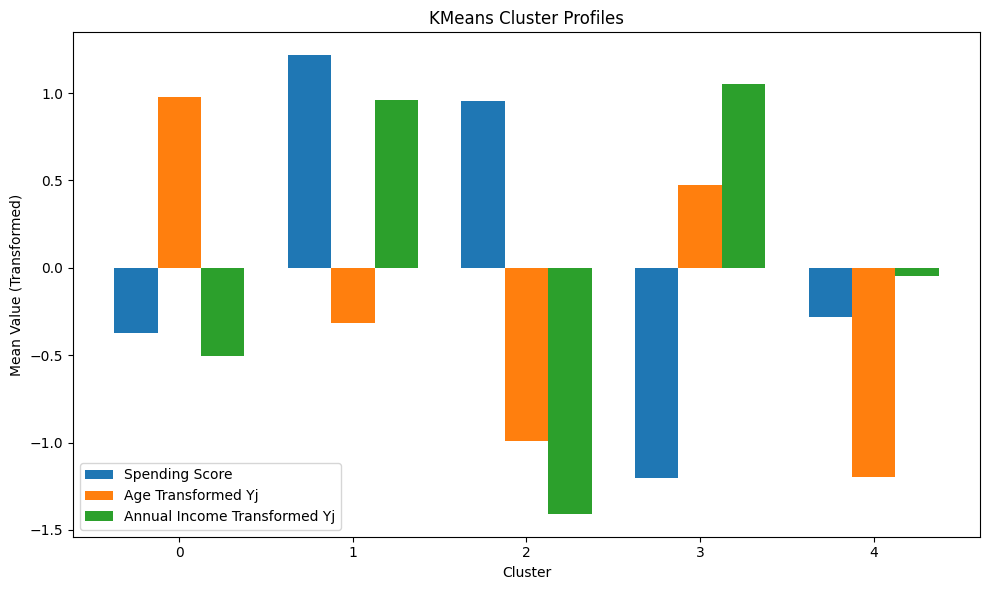

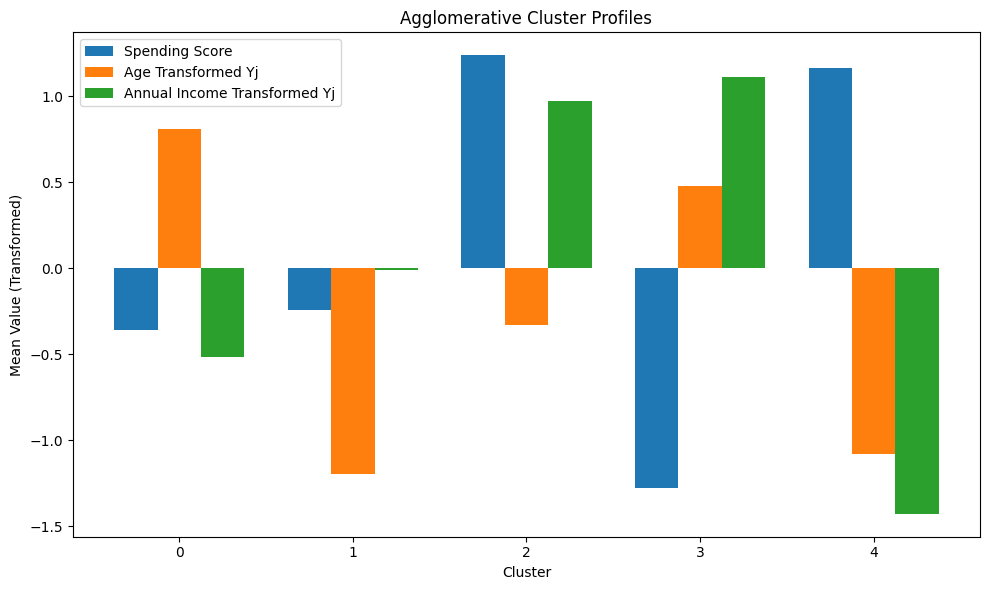

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Features to visualize
features = ['spending_score_mean', 'age_transformed_yj_mean', 'annual_income_transformed_yj_mean']

# Function to plot cluster profiles
def plot_cluster_profiles(summary_df, title):
    clusters = summary_df['Cluster'].astype(str)
    x = np.arange(len(clusters))
    width = 0.25
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for i, feature in enumerate(features):
        ax.bar(x + i*width, summary_df[feature], width, label=feature.replace('_mean','').replace('_',' ').title())
    
    ax.set_xticks(x + width)
    ax.set_xticklabels(clusters)
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Mean Value (Transformed)")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

# Plot for KMeans
plot_cluster_profiles(kmeans_summary, "KMeans Cluster Profiles")

# Plot for Agglomerative
plot_cluster_profiles(agg_summary, "Agglomerative Cluster Profiles")


### RADARplot

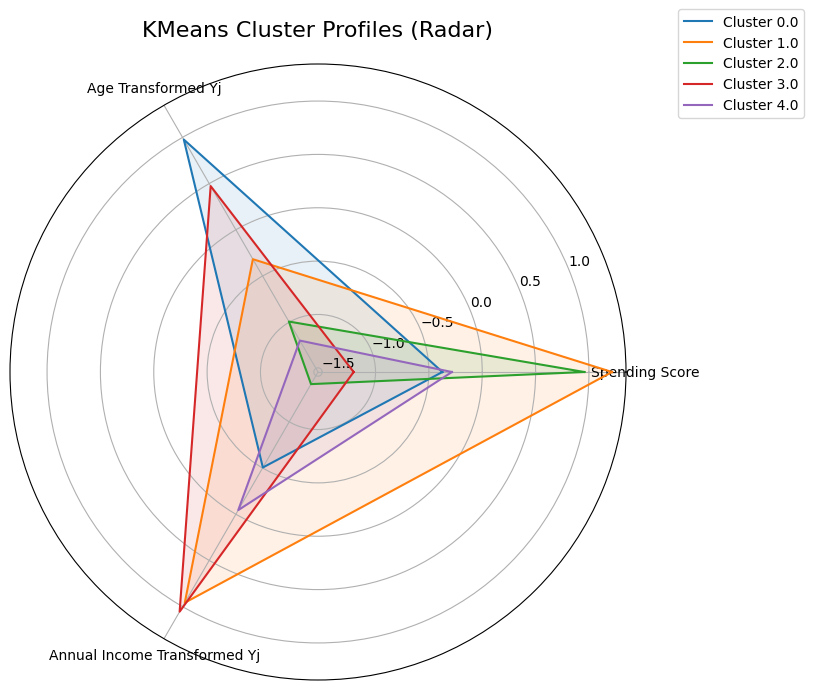

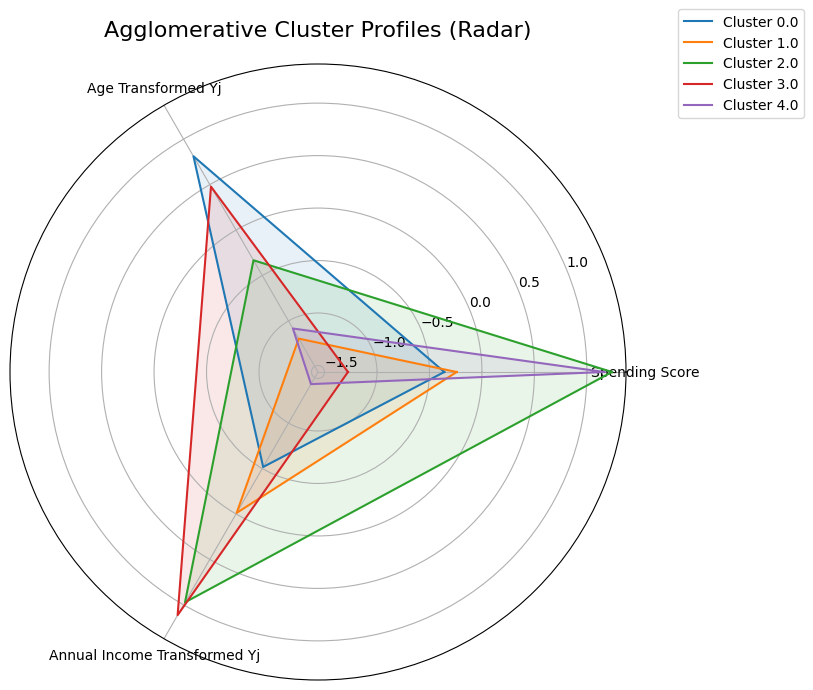

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_radar(summary_df, title):
    features = ['spending_score_mean', 'age_transformed_yj_mean', 'annual_income_transformed_yj_mean']
    labels = [f.replace('_mean','').replace('_',' ').title() for f in features]
    num_features = len(features)
    
    angles = np.linspace(0, 2 * np.pi, num_features, endpoint=False).tolist()
    angles += angles[:1]  # Complete the loop
    
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    
    for i, row in summary_df.iterrows():
        values = row[features].tolist()
        values += values[:1]  # Complete the loop
        ax.plot(angles, values, label=f'Cluster {row["Cluster"]}')
        ax.fill(angles, values, alpha=0.1)
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.set_title(title, size=16, pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.show()

# Radar plot for KMeans
plot_radar(kmeans_summary, "KMeans Cluster Profiles (Radar)")

# Radar plot for Agglomerative
plot_radar(agg_summary, "Agglomerative Cluster Profiles (Radar)")


Single radar chart overlaying all clusters from both KMeans and Agglomerative

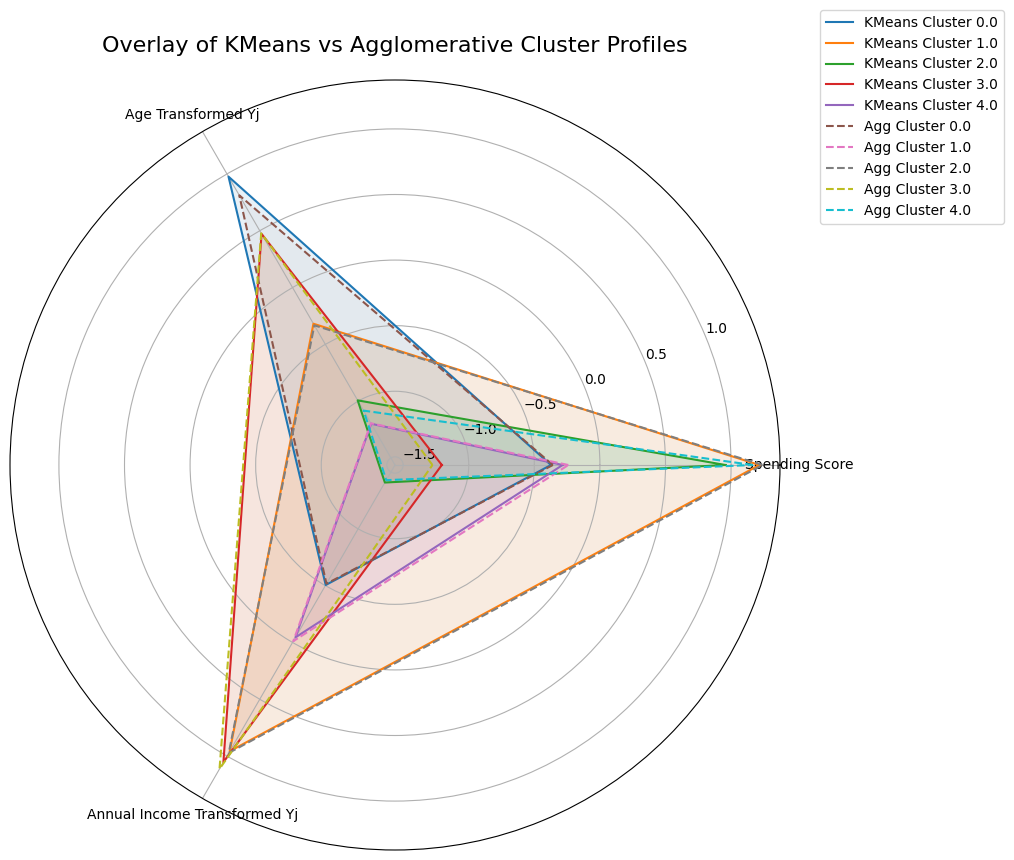

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_overlay_radar(kmeans_df, agg_df, title):
    features = ['spending_score_mean', 'age_transformed_yj_mean', 'annual_income_transformed_yj_mean']
    labels = [f.replace('_mean','').replace('_',' ').title() for f in features]
    num_features = len(features)
    
    angles = np.linspace(0, 2 * np.pi, num_features, endpoint=False).tolist()
    angles += angles[:1]  # Complete the loop
    
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
    
    # Plot KMeans clusters
    for i, row in kmeans_df.iterrows():
        values = row[features].tolist()
        values += values[:1]
        ax.plot(angles, values, label=f'KMeans Cluster {row["Cluster"]}', linestyle='solid')
        ax.fill(angles, values, alpha=0.1)
    
    # Plot Agglomerative clusters
    for i, row in agg_df.iterrows():
        values = row[features].tolist()
        values += values[:1]
        ax.plot(angles, values, label=f'Agg Cluster {row["Cluster"]}', linestyle='dashed')
        ax.fill(angles, values, alpha=0.05)
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.set_title(title, size=16, pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.show()

# Overlay radar chart
plot_overlay_radar(kmeans_summary, agg_summary, "Overlay of KMeans vs Agglomerative Cluster Profiles")


KMeans clusters → solid lines

Agglomerative clusters → dashed lines

Shaded areas help highlight cluster profiles.

- Differences in shape or magnitude between KMeans and Agglomerative clusters are immediately visible.

- Easy for presentations—stakeholders can see which clusters match or differ across algorithms.

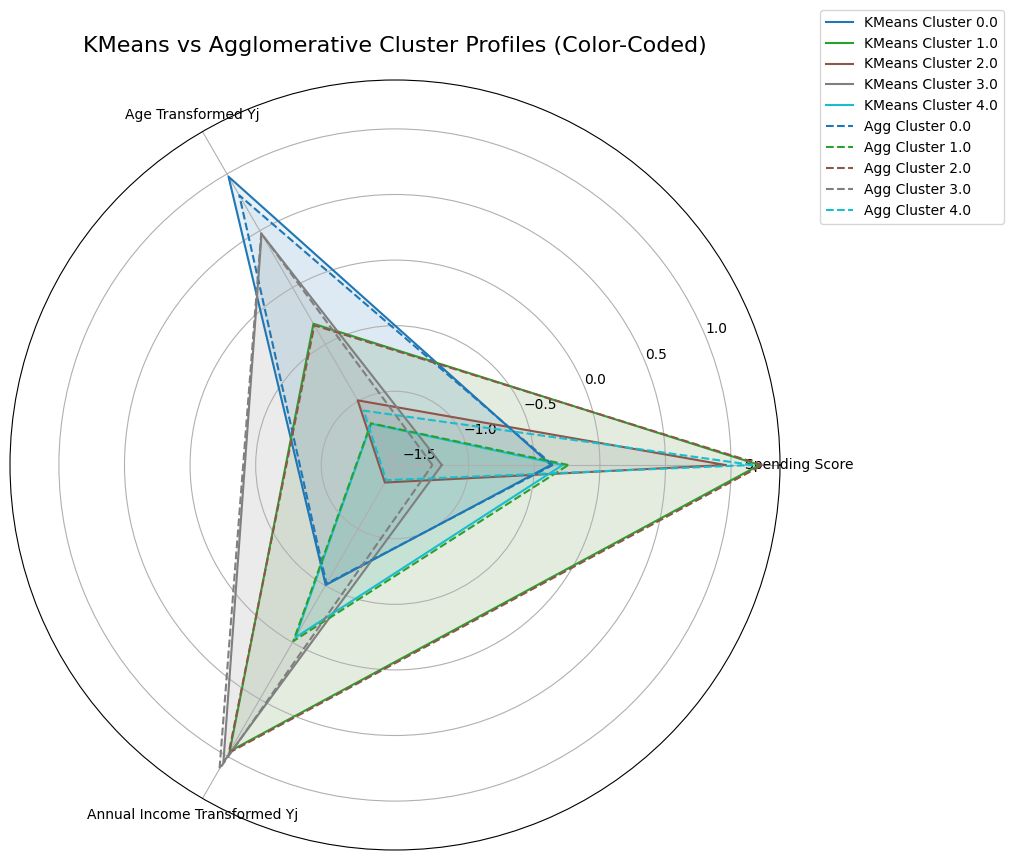

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_colored_overlay_radar(kmeans_df, agg_df, title):
    features = ['spending_score_mean', 'age_transformed_yj_mean', 'annual_income_transformed_yj_mean']
    labels = [f.replace('_mean','').replace('_',' ').title() for f in features]
    num_features = len(features)
    
    angles = np.linspace(0, 2 * np.pi, num_features, endpoint=False).tolist()
    angles += angles[:1]  # Complete the loop
    
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
    
    # Define color palette
    colors = plt.cm.tab10(np.linspace(0, 1, len(kmeans_df)))
    
    # Plot KMeans clusters with solid lines
    for i, row in kmeans_df.iterrows():
        values = row[features].tolist()
        values += values[:1]
        ax.plot(angles, values, label=f'KMeans Cluster {row["Cluster"]}', linestyle='solid', color=colors[i])
        ax.fill(angles, values, alpha=0.1, color=colors[i])
    
    # Plot Agglomerative clusters with dashed lines, same color for approximate matching
    for i, row in agg_df.iterrows():
        values = row[features].tolist()
        values += values[:1]
        color_idx = i % len(colors)  # Assign matching color by index (you can refine manually if needed)
        ax.plot(angles, values, label=f'Agg Cluster {row["Cluster"]}', linestyle='dashed', color=colors[color_idx])
        ax.fill(angles, values, alpha=0.05, color=colors[color_idx])
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.set_title(title, size=16, pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.show()

# Overlay radar chart with color coding
plot_colored_overlay_radar(kmeans_summary, agg_summary, "KMeans vs Agglomerative Cluster Profiles (Color-Coded)")


## Model Selection

-----

## Cross-Validation

---

## Hyperparameter Tuning

### K Maens

In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

labels_dict = {
    "KMeans": kmeans.labels_,
    "Agglomerative": agg.labels_,
    "GMM": gmm.predict(X),
    "Spectral": spectral.labels_
}

for name, labels in labels_dict.items():
    sil = silhouette_score(X, labels)
    db = davies_bouldin_score(X, labels)
    ch = calinski_harabasz_score(X, labels)
    print(f"{name}: Silhouette={sil:.3f}, DB={db:.3f}, CH={ch:.3f}")


KMeans: Silhouette=0.363, DB=1.044, CH=98.159
Agglomerative: Silhouette=0.350, DB=1.005, CH=88.686
GMM: Silhouette=0.320, DB=1.129, CH=81.878
Spectral: Silhouette=0.290, DB=1.235, CH=83.429


Select the best performing algorithm (higher silhouette, lower DB)

KMeans as the primary choice, given its strong performance on Silhouette score and CH index. If you prioritize hierarchical structures or complex distributions, consider Agglomerative or GMM, respectively.

In [ ]:
from sklearn.model_selection import ParameterGrid

param_grid = {'n_clusters':[4,5,6,7], 'init':['k-means++','random'], 'max_iter':[300,500]}
best_score = -1

for params in ParameterGrid(param_grid):
    model = KMeans(**params, random_state=42)
    labels = model.fit_predict(X)
    score = silhouette_score(X, labels)
    if score > best_score:
        best_score = score
        best_params = params

print("Best Silhouette Score:", best_score)
print("Best Parameters:", best_params)


Best Silhouette Score: 0.38554954594936897
Best Parameters: {'init': 'random', 'max_iter': 300, 'n_clusters': 6}


### plot clusters in 3D using PCA or t-SNE:

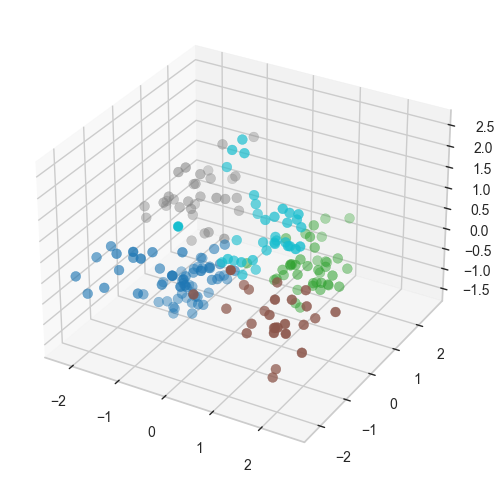

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=3)
X_3d = pca.fit_transform(X)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_3d[:,0], X_3d[:,1], X_3d[:,2], c=kmeans.labels_, cmap='tab10', s=50)
plt.show()


Step 3: Finalize Clustering Model

Once you have the best parameters, fit the model on entire dataset:

In [ ]:
final_model = KMeans(**best_params, random_state=42)
final_labels = final_model.fit_predict(X)
df['cluster'] = final_labels


### Part 2: Model Explanation & Understanding
Step 4: Manual Cluster Analysis

Calculate mean of features per cluster:

In [ ]:
cluster_summary = df.groupby('cluster').mean()
print(cluster_summary)


         spending_score  age_transformed_yj  annual_income_transformed_yj  \
cluster                                                                     
0             -0.241835           -1.187612                      0.010897   
1             -0.051914            1.052793                     -0.166762   
2             -1.231270            0.484816                      1.078030   
3              1.010913           -1.014502                     -1.389248   
4              1.239503           -0.332722                      0.972336   
5             -1.228702            0.499788                     -1.423724   

         gender_Male  cluster_0  cluster_1  cluster_2  cluster_3  cluster_4  
cluster                                                                      
0           0.411765   0.000000   0.000000       0.00   0.000000       1.00  
1           0.431373   0.960784   0.019608       0.00   0.019608       0.00  
2           0.516129   0.000000   0.000000       0.00   1.000000       

Step 5: Classification for Model Explanation

Treat cluster labels as target for supervised learning.

Train a classifier (e.g., Random Forest):

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, df['cluster'], test_size=0.2, random_state=42)
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

Step 6: Explainability (SHAP & LIME)

SHAP for global and local explanations:

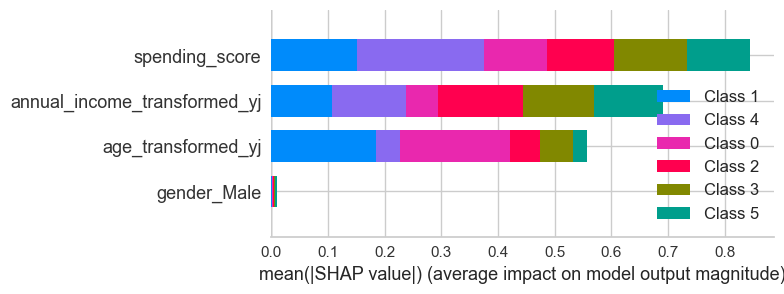

In [ ]:
import shap

explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_train)
shap.summary_plot(shap_values, X_train, feature_names=df.columns[:-2])


LIME for local explanation:

In [ ]:
from lime.lime_tabular import LimeTabularExplainer

explainer = LimeTabularExplainer(X_train.values, feature_names=X_train.columns, class_names=[str(i) for i in df['cluster'].unique()], discretize_continuous=True)
i = 0  # pick a sample
exp = explainer.explain_instance(X_test.values[i], clf.predict_proba)
exp.show_in_notebook()


---
---

---

## Final Training

---

## Final Evaluation

---

---
___

# Clustering Analysis

In [ ]:
df['cluster'] = kmeans.labels_  # or agg.labels_
df

,spending_score,age_transformed_yj,annual_income_transformed_yj,gender_Male,cluster
0,-0.434801,-1.718993,-1.993334,1.0,2
1,1.195704,-1.470002,-1.993334,1.0,2
2,-1.715913,-1.591912,-1.933217,0.0,4
3,1.040418,-1.240020,-1.933217,0.0,2
4,-0.395980,-0.461118,-1.874401,0.0,2
...,...,...,...,...,...
195,1.118061,-0.133840,2.026598,0.0,1
196,-0.861839,0.563320,2.201402,0.0,3
197,0.923953,-0.376090,2.201402,1.0,1
198,-1.250054,-0.376090,2.514502,1.0,3


In [ ]:
X = df.drop(columns=['cluster'])
y = df['cluster']


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00         5
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00        10
           4       1.00      1.00      1.00        10

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



Use Clusters as Features (Feature Engineering)

Instead of predicting clusters, you can use the cluster ID as a feature in another supervised model (e.g., predicting spending, churn, etc.).

Steps:

In [ ]:
df['cluster'] = kmeans.labels_


In [ ]:
df = pd.get_dummies(df, columns=['cluster'], prefix='cluster')


In [ ]:
from sklearn.linear_model import LinearRegression

X = df.drop(columns=['target'])
y = df['target']
model = LinearRegression()
model.fit(X, y)


KeyError: "['target'] not found in axis"

# PyCaret for Clustering

In [ ]:
from pycaret.clustering import *

# Assume your DataFrame is `df`
# Initialize PyCaret clustering
clu_setup = setup(data=df, normalize=True, session_id=42, silent=True)


TypeError: setup() got an unexpected keyword argument 'silent'

In [ ]:
# Assume your DataFrame is `df`
# Initialize PyCaret clustering
clu_setup = setup(data=df, normalize=True, session_id=42, verbose=False)

In [ ]:
best_model = compare_models()


NameError: name 'compare_models' is not defined

In [ ]:
# Step 1: Import PyCaret
from pycaret.clustering import setup, compare_models, create_model, assign_model, plot_model, save_model, load_model

from pycaret.clustering import *
import pandas as pd

# Assume your dataset is `df`
# Step 2: Setup PyCaret clustering
clu_setup = setup(data=df, normalize=True, session_id=42)

# Step 3: Compare multiple clustering models
best_model = compare_models()  # Automatically ranks algorithms

# Step 4: Create a specific clustering model (e.g., KMeans with 5 clusters)
kmeans_model = create_model('kmeans', num_clusters=5)

# If you want Agglomerative Clustering
agg_model = create_model('hclust', num_clusters=5)

# Step 5: Assign cluster labels to original data
kmeans_clusters = assign_model(kmeans_model)
agg_clusters = assign_model(agg_model)

# Inspect first few rows
print("KMeans clusters:\n", kmeans_clusters.head())
print("Agglomerative clusters:\n", agg_clusters.head())

# Step 6: Plot clusters
# 2D visualization using PCA
plot_model(kmeans_model, plot='pca')
plot_model(agg_model, plot='pca')

# 2D visualization using t-SNE
plot_model(kmeans_model, plot='tsne')
plot_model(agg_model, plot='tsne')

# Elbow / silhouette analysis
plot_model(kmeans_model, plot='elbow')
plot_model(kmeans_model, plot='silhouette')

# Step 7: Generate cluster summary table
def cluster_summary_pycaret(df_clustered):
    summary = df_clustered.groupby('Cluster').agg(['mean', 'min', 'max', 'count'])
    return summary

print("KMeans cluster summary:\n", cluster_summary_pycaret(kmeans_clusters))
print("Agglomerative cluster summary:\n", cluster_summary_pycaret(agg_clusters))

# Step 8: Save models for future use
save_model(kmeans_model, 'kmeans_cluster_model')
save_model(agg_model, 'agg_cluster_model')

# Step 9: Load model and predict on new data
# loaded_model = load_model('kmeans_cluster_model')
# new_data_clusters = assign_model(loaded_model, data=new_data)


ImportError: cannot import name 'compare_models' from 'pycaret.clustering' (c:\Users\anilj.ANIL_JOSEPH\miniconda3\envs\ml_env\lib\site-packages\pycaret\clustering\__init__.py)

If you want, I can write a full end-to-end Python notebook implementing Part 1 + Part 2, ready to run, including cluster analysis, SHAP/LIME explainability, and final model export.

In [ ]:
# PyCaret End-to-End Notebook for Customer Segmentation

In [ ]:
# ===========================================
# Customer Segmentation with PyCaret
# ===========================================

# Part 0: Setup
import pandas as pd
import numpy as np
from pycaret.clustering import *
import joblib, os

# # Load dataset
# df = pd.read_csv("your_data.csv")  # replace with your CSV
# df.head()


Part 1: Initialize PyCaret Clustering

In [ ]:
from pycaret.clustering import *

# Setup
setup(
    data=df,
    normalize=True,
    session_id=42
)

,Description,Value
0,Session id,42
1,Original data shape,"(200, 4)"
2,Transformed data shape,"(200, 4)"
3,Numeric features,4
4,Preprocess,True
5,Imputation type,simple
6,Numeric imputation,mean
7,Categorical imputation,mode
8,Normalize,True
9,Normalize method,zscore


In [ ]:


# Create KMeans model
kmeans = create_model('kmeans', num_clusters=5)

# Create Agglomerative model
agg = create_model('hclust', num_clusters=5)

# Plot KMeans clusters
plot_model(kmeans, plot='cluster')

# Plot Agglomerative clusters
plot_model(agg, plot='cluster')

# Assign clusters back to data
kmeans_results = assign_model(kmeans)
agg_results = assign_model(agg)

print(kmeans_results.head())
print(agg_results.head())


,Description,Value
0,Session id,42
1,Original data shape,"(200, 4)"
2,Transformed data shape,"(200, 4)"
3,Numeric features,4
4,Preprocess,True
5,Imputation type,simple
6,Numeric imputation,mean
7,Categorical imputation,mode
8,Normalize,True
9,Normalize method,zscore


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.3055,66.9391,1.1660,0,0,0


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.2820,58.9128,1.2532,0,0,0


   spending_score  age_transformed_yj  annual_income_transformed_yj  \
0       -0.434801           -1.718993                     -1.993334   
1        1.195704           -1.470002                     -1.993334   
2       -1.715913           -1.591912                     -1.933218   
3        1.040418           -1.240020                     -1.933218   
4       -0.395980           -0.461118                     -1.874401   

   gender_Male    Cluster  
0          1.0  Cluster 2  
1          1.0  Cluster 4  
2          0.0  Cluster 2  
3          0.0  Cluster 2  
4          0.0  Cluster 2  
   spending_score  age_transformed_yj  annual_income_transformed_yj  \
0       -0.434801           -1.718993                     -1.993334   
1        1.195704           -1.470002                     -1.993334   
2       -1.715913           -1.591912                     -1.933218   
3        1.040418           -1.240020                     -1.933218   
4       -0.395980           -0.461118             

2. Train Models

In [ ]:
# Train KMeans
kmeans = create_model('kmeans', num_clusters=5)

# Train Agglomerative (Hierarchical Clustering)
agg = create_model('hclust', num_clusters=5)


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.3055,66.9391,1.1660,0,0,0


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.2820,58.9128,1.2532,0,0,0


3. Visualize Clusters

In [ ]:
# KMeans Clusters
plot_model(kmeans, plot='cluster')

# Agglomerative Clusters
plot_model(agg, plot='cluster')


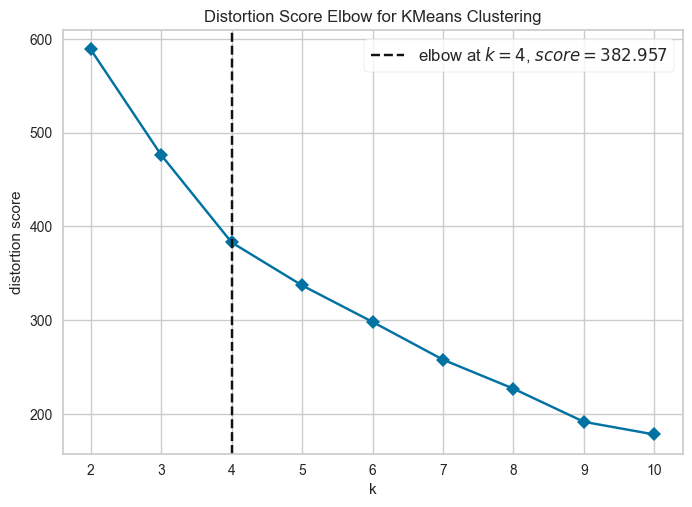

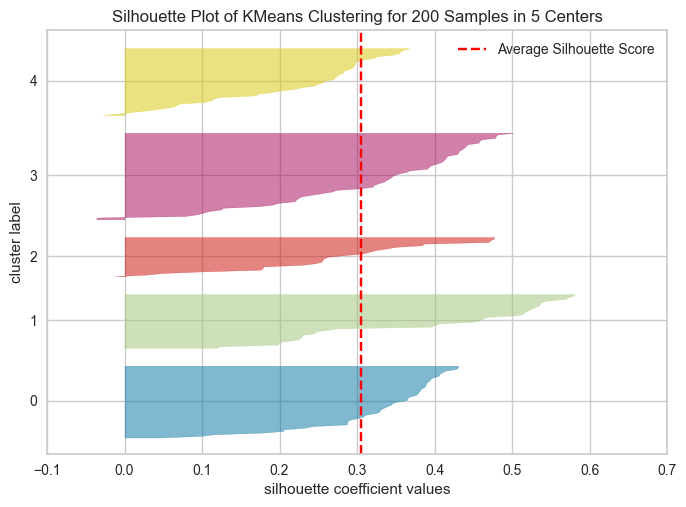

In [ ]:
plot_model(kmeans, plot='elbow')       # elbow curve for KMeans
plot_model(kmeans, plot='silhouette')  # silhouette plot


4. Assign Clusters Back to Data

In [ ]:
# Add cluster labels to dataset
kmeans_results = assign_model(kmeans)
agg_results = assign_model(agg)

print("KMeans clustering results:")
print(kmeans_results.head())

print("\nAgglomerative clustering results:")
print(agg_results.head())


KMeans clustering results:
   spending_score  age_transformed_yj  annual_income_transformed_yj  \
0       -0.434801           -1.718993                     -1.993334   
1        1.195704           -1.470002                     -1.993334   
2       -1.715913           -1.591912                     -1.933218   
3        1.040418           -1.240020                     -1.933218   
4       -0.395980           -0.461118                     -1.874401   

   gender_Male    Cluster  
0          1.0  Cluster 2  
1          1.0  Cluster 4  
2          0.0  Cluster 2  
3          0.0  Cluster 2  
4          0.0  Cluster 2  

Agglomerative clustering results:
   spending_score  age_transformed_yj  annual_income_transformed_yj  \
0       -0.434801           -1.718993                     -1.993334   
1        1.195704           -1.470002                     -1.993334   
2       -1.715913           -1.591912                     -1.933218   
3        1.040418           -1.240020                     -

5. Interpret Clusters (Manual Analysis)

In [ ]:
# Example: interpret KMeans clusters
kmeans_results.groupby('Cluster').mean()


,spending_score,age_transformed_yj,annual_income_transformed_yj,gender_Male
Cluster,,,,
Cluster 0,-0.756589,0.874458,0.045858,1.00
Cluster 1,0.708151,-0.701916,0.655340,0.00
Cluster 2,0.406850,-0.852876,-1.293585,0.04
Cluster 3,-0.535450,0.744332,0.047166,0.00
Cluster 4,0.683629,-0.818036,0.129701,1.00


Part 2: Model Explanation & Understanding

We’ll take the cluster labels from KMeans (or Agglomerative) and use them as a target variable to train a classification model.
Then we’ll explain that model using SHAP and LIME.

1. Assign Clusters

In [ ]:
# Assign KMeans clusters
kmeans_results = assign_model(kmeans)

# Assign Agglomerative clusters
agg_results = assign_model(agg)

# Let's pick KMeans results for explanation
df_with_clusters = kmeans_results.copy()


2. Setup Classification Task

In [ ]:
from pycaret.classification import *

# Setup classification using cluster labels as target
clf_setup = setup(
    data=df_with_clusters,
    target='Cluster',
    normalize=True,
    session_id=42
)


,Description,Value
0,Session id,42
1,Target,Cluster
2,Target type,Multiclass
3,Target mapping,"Cluster 0: 0, Cluster 1: 1, Cluster 2: 2, Cluster 3: 3, Cluster 4: 4"
4,Original data shape,"(200, 5)"
5,Transformed data shape,"(200, 5)"
6,Transformed train set shape,"(140, 5)"
7,Transformed test set shape,"(60, 5)"
8,Numeric features,4
9,Preprocess,True


3. Train Classifiers

In [ ]:
# Compare multiple classifiers (RandomForest, XGBoost, etc.)
best_clf = compare_models()

# Create a RandomForest (example)
rf_model = create_model('rf')

# Evaluate performance
evaluate_model(rf_model)


,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,03:38:50
Status,. . . . . . . . . . . . . . . . . .,Fitting 10 Folds
Estimator,. . . . . . . . . . . . . . . . . .,K Neighbors Classifier


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)


Processing:   0%|          | 0/69 [00:00<?, ?it/s]

4. Interpret Model with SHAP & LIME

In [ ]:
# SHAP summary plot
interpret_model(rf_model, plot='summary')

# LIME explanation for a single prediction
interpret_model(rf_model, plot='lime')
